# 🧰 NLTK and spaCy: from raw text to tags, entities and sentiment

### Human Language Technologies 2026-27 · Lab


# 🛠️ NLTK · the Natural Language Toolkit

[NLTK](https://www.nltk.org) is the classic Python library for teaching and research in NLP. Think of it as a **toolbox**: many small, independent functions that you choose and combine yourself.

| What it gives you                                                                 | What we use in this notebook                                                             |
| --------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| tokenizers                                                                        | `sent_tokenize` (Punkt), `word_tokenize` (Penn Treebank conventions, L03)                |
| 50+ corpora and lexical resources, downloaded on demand with `nltk.download(...)` | stopword lists, WordNet, the VADER lexicon, a sample of the Penn Treebank, movie reviews |
| counting and statistics                                                           | `FreqDist`, n-grams, collocation finders with PMI                                        |
| classic algorithms                                                                | Porter stemmer, WordNet lemmatizer, PoS tagger, named entity chunker, VADER              |

Most NLTK functions take **lists of tokens** (strings), so the first step is always tokenization. We start from a real book: _The Adventures of Pinocchio_ (an English translation), downloaded from Project Gutenberg.


In [1]:
import requests

url_pinocchio = "https://www.gutenberg.org/files/500/500-0.txt"
text = requests.get(url_pinocchio).content.decode()
text[:500]  # this is a massive string: we only look at the beginning

'\ufeffThe Project Gutenberg EBook of The Adventures of Pinocchio, by\r\nC. Collodi--Pseudonym of Carlo Lorenzini\r\n\r\nThis eBook is for the use of anyone anywhere at no cost and with\r\nalmost no restrictions whatsoever.  You may copy it, give it away or\r\nre-use it under the terms of the Project Gutenberg License included\r\nwith this eBook or online at www.gutenberg.org\r\n\r\n\r\nTitle: The Adventures of Pinocchio\r\n\r\nAuthor: C. Collodi--Pseudonym of Carlo Lorenzini\r\n\r\nRelease Date: January 12, 2006 [EBook #500]\r'

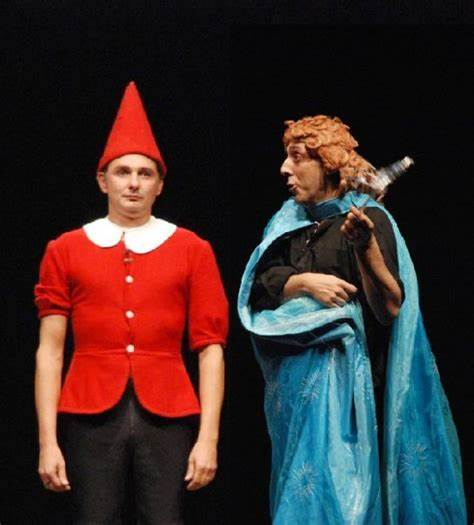


In [2]:
print(text)

The Project Gutenberg EBook of The Adventures of Pinocchio, by
C. Collodi--Pseudonym of Carlo Lorenzini

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.org


Title: The Adventures of Pinocchio

Author: C. Collodi--Pseudonym of Carlo Lorenzini

Release Date: January 12, 2006 [EBook #500]
[Most recently updated: September 28, 2020]

Language: English

Character set encoding: UTF-8

*** START OF THIS PROJECT GUTENBERG EBOOK THE ADVENTURES OF PINOCCHIO ***




Produced by Charles Keller (for Tina); and David Widger







Dashes; small checks; quick pass; gutchecked twice; jeebies; spellcheck


THE ADVENTURES OF PINOCCHIO

by C. Collodi

[Pseudonym of Carlo Lorenzini]


Translated from the Italian by Carol Della Chiesa




CHAPTER 1

How it happened that Mastro Cherry, carpenter, found a piece o

## ✂️ Tokenization


#### Splitting text into sentences with `sent_tokenize`

The Punkt Sentence Tokenizer **divides a text into a list of sentences**.

Punkt is a pre-trained sentence tokenizer available in NLTK. It is trained on large datasets to recognize common abbreviations, proper nouns, and sentence-ending punctuation. It works well for many languages without requiring manual configuration.


In [3]:
import nltk

# nltk.download('punkt')
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/federico/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
sentences = nltk.sent_tokenize(text)
sentences[42]

'He listened for the tiny voice to moan and cry.'

#### Splitting text into words with `word_tokenize`

Tokenization of the whole text


In [5]:
tokenized_text = nltk.word_tokenize(text)
tokenized_text[1000:1010]

['Mastro',
 'Cherry',
 'gives',
 'the',
 'piece',
 'of',
 'wood',
 'to',
 'his',
 'friend']

Tokenization of each sentence


In [ ]:
tokenized_sentences = []
for sent in nltk.sent_tokenize(text):
    tokenized_sentences.append(nltk.word_tokenize(sent))

In [7]:
tokenized_sentences[42]

['He',
 'listened',
 'for',
 'the',
 'tiny',
 'voice',
 'to',
 'moan',
 'and',
 'cry',
 '.']

## 🧮 Counting frequencies with `FreqDist`


In [8]:
freq_dist = nltk.FreqDist(tokenized_text)
freq_dist

FreqDist({',': 3345, '.': 2322, 'the': 2100, 'and': 1357, '“': 1316, '”': 1313, 'to': 1298, 'a': 1085, 'of': 860, 'I': 796, ...})

In [9]:
freq_dist.most_common(20)

[(',', 3345),
 ('.', 2322),
 ('the', 2100),
 ('and', 1357),
 ('“', 1316),
 ('”', 1313),
 ('to', 1298),
 ('a', 1085),
 ('of', 860),
 ('I', 796),
 ('he', 728),
 ('you', 702),
 ('!', 616),
 ('his', 555),
 ('?', 485),
 ('in', 473),
 ('’', 458),
 ('Pinocchio', 457),
 ('that', 434),
 ('was', 390)]

<Axes: xlabel='Samples', ylabel='Counts'>

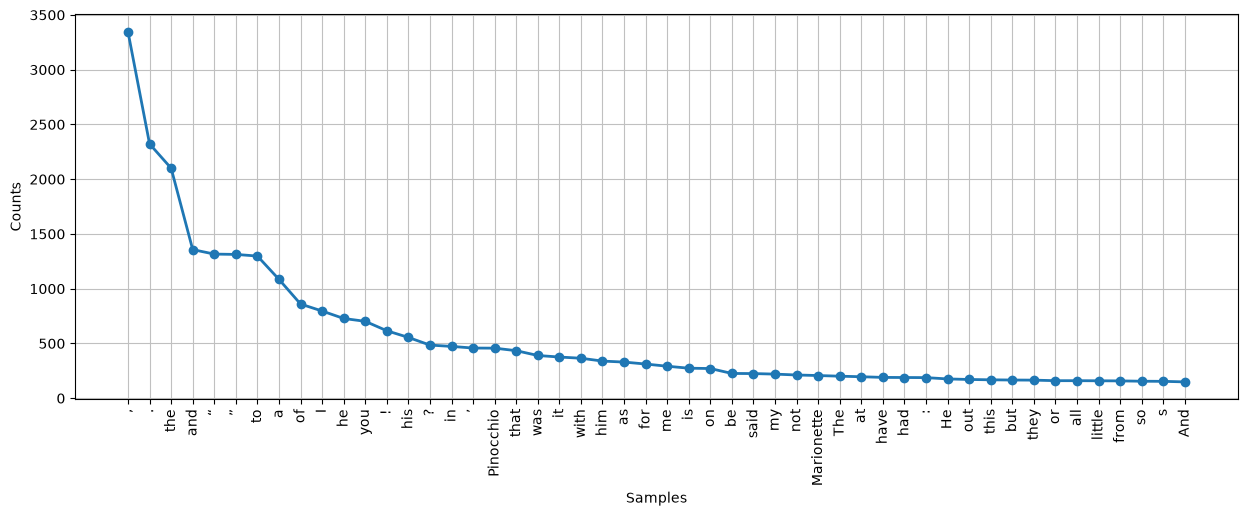

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
freq_dist.plot(50, marker="o")

In [11]:
tokenized_text.count("Pinocchio")

457

## 🔍 Inspecting text with the `NLTK.Text` object

- concordance
- collocations (Bigram, Trigram, Quadgram)
- dispersion plot


In [12]:
nltk_text = nltk.Text(tokenized_text)

A **concordance view** shows us every occurrence of a given word, together with some context.


In [13]:
nltk_text.concordance("Pinocchio")

Displaying 25 of 463 matches:
tenberg EBook of The Adventures of Pinocchio , by C. Collodi -- Pseudonym of Ca
berg.org Title : The Adventures of Pinocchio Author : C. Collodi -- Pseudonym o
 GUTENBERG EBOOK THE ADVENTURES OF PINOCCHIO * * * Produced by Charles Keller (
ies ; spellcheck THE ADVENTURES OF PINOCCHIO by C. Collodi [ Pseudonym of Carlo
shions the Marionette and calls it Pinocchio . The first pranks of the Marionet
imself . “ I think I ’ ll call him PINOCCHIO . This name will make his fortune 
a whole family of Pinocchi once -- Pinocchio the father , Pinocchia the mother 
was in the Marionette ’ s hand . “ Pinocchio , give me my wig ! ” But instead o
 ” But instead of giving it back , Pinocchio put it on his own head , which was
o than he had ever been before . “ Pinocchio , you wicked boy ! ” he cried out 
n the floor to teach him to walk . Pinocchio ’ s legs were so stiff that he cou
. When his legs were limbered up , Pinocchio started walking by himself and ran
 but was u

In [14]:
nltk_text.concordance("Pinocchio", width=100, lines=10)

Displaying 10 of 463 matches:
Project Gutenberg EBook of The Adventures of Pinocchio , by C. Collodi -- Pseudonym of Carlo Lorenz
 www.gutenberg.org Title : The Adventures of Pinocchio Author : C. Collodi -- Pseudonym of Carlo Lo
IS PROJECT GUTENBERG EBOOK THE ADVENTURES OF PINOCCHIO * * * Produced by Charles Keller ( for Tina 
ice ; jeebies ; spellcheck THE ADVENTURES OF PINOCCHIO by C. Collodi [ Pseudonym of Carlo Lorenzini
eppetto fashions the Marionette and calls it Pinocchio . The first pranks of the Marionette . Littl
 said to himself . “ I think I ’ ll call him PINOCCHIO . This name will make his fortune . I knew a
 . I knew a whole family of Pinocchi once -- Pinocchio the father , Pinocchia the mother , and Pino
ellow wig was in the Marionette ’ s hand . “ Pinocchio , give me my wig ! ” But instead of giving i
e my wig ! ” But instead of giving it back , Pinocchio put it on his own head , which was half swal
t , more so than he had ever been before . “ Pinocchio , you wicked bo

## 🛑 Stopword removal


In [15]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/federico/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
from nltk.corpus import stopwords

# it provides a predefined list of stopwords for several languages
stopwords.words("english")[:5]

['a', 'about', 'above', 'after', 'again']

In [17]:
features = set(nltk.word_tokenize("the president of the united states of america"))
less_features = features.difference(stopwords.words("english"))
less_features

{'america', 'president', 'states', 'united'}

### 🧹 Removing stopwords from Pinocchio


In [18]:
stop_set = set(
    stopwords.words("english")
)  # a set: membership tests are much faster than on a list
freq_dist = nltk.FreqDist(tokenized_text)
filtered_freq_dist = nltk.FreqDist({
    k: v for (k, v) in freq_dist.items() if k.lower() not in stop_set and k.isalnum()
})
filtered_freq_dist.most_common(20)

[('Pinocchio', 457),
 ('said', 225),
 ('Marionette', 207),
 ('little', 159),
 ('one', 147),
 ('like', 105),
 ('two', 105),
 ('poor', 93),
 ('Fairy', 92),
 ('good', 89),
 ('want', 86),
 ('Project', 83),
 ('go', 80),
 ('cried', 79),
 ('answered', 78),
 ('long', 76),
 ('Geppetto', 75),
 ('work', 74),
 ('time', 71),
 ('could', 71)]

<Axes: xlabel='Samples', ylabel='Counts'>

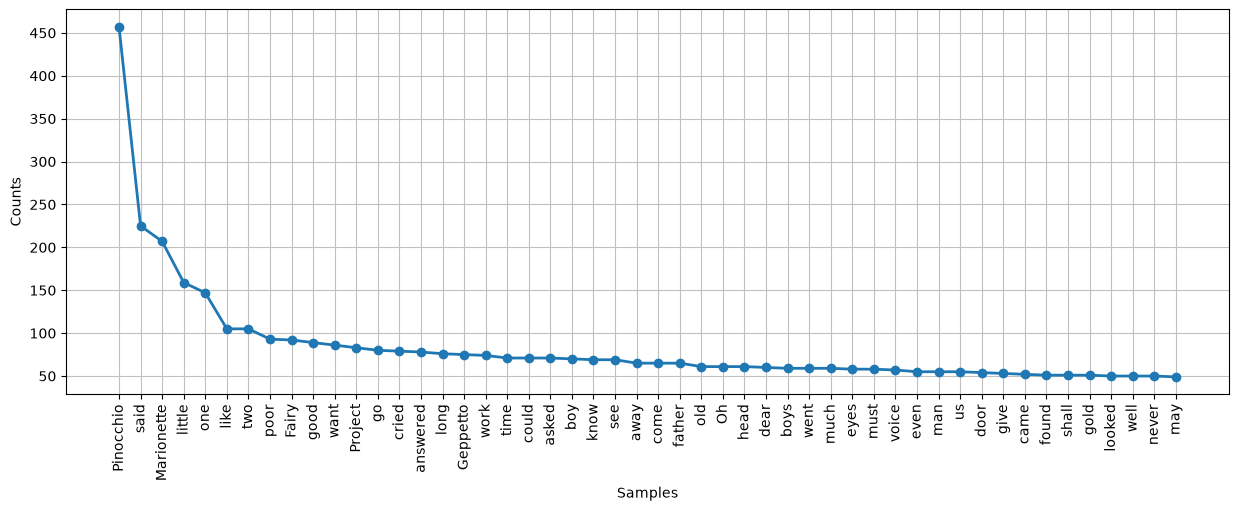

In [19]:
plt.figure(figsize=(15, 5))
filtered_freq_dist.plot(50, marker="o")

### 💑 Collocations

**Collocations** are expressions of multiple words which commonly co-occur: _gold pieces_, _Talking Cricket_, _strong tea_ (but not _powerful tea_).

To find them we need a score that says how much more often two words occur **together** than they would if they were **independent**. A classic one is **pointwise mutual information** (PMI):

$$
\text{PMI}(w_1, w_2) \;=\; \log_2 \frac{P(w_1\,w_2)}{P(w_1)\,P(w_2)} .
$$

If $w_1$ and $w_2$ were independent, $P(w_1 w_2) = P(w_1)P(w_2)$ and PMI would be 0; a positive PMI means they co-occur more than chance.

Since $P(w_1 w_2) = P(w_1)\,P(w_2 \mid w_1)$, the same score can be written with the conditional probability we know from n-gram models:

$$
\text{PMI}(w_1, w_2) \;=\; \log_2 \frac{P(w_2 \mid w_1)}{P(w_2)} :
$$

how much more probable $w_2$ becomes once we know that the previous word is $w_1$. Both probabilities are maximum likelihood estimates we have already seen:

- the **bigram** probability of L04: $P(w_2 \mid w_1) = \dfrac{C(w_1\,w_2)}{C(w_1)}$;
- the **unigram** probability: $P(w_2) = \dfrac{C(w_2)}{N}$, where $N$ is the **total number of tokens** in the text (here `len(tokenized_text)`).

Putting them together,

$$
\text{PMI}(w_1, w_2) \;=\; \log_2 \frac{C(w_1\,w_2)/C(w_1)}{C(w_2)/N} \;=\; \log_2 \frac{C(w_1\,w_2)\cdot N}{C(w_1)\,C(w_2)} .
$$

We will meet PMI again in the lecture on word embeddings.


In [ ]:
# nltk.download('stopwords')   # used below to filter the candidate bigrams
# from nltk.corpus import stopwords
from nltk.collocations import (
    BigramAssocMeasures,
    BigramCollocationFinder,
    QuadgramAssocMeasures,
    QuadgramCollocationFinder,
    TrigramAssocMeasures,
    TrigramCollocationFinder,
)

bigram_measures = BigramAssocMeasures()
trigram_measures = TrigramAssocMeasures()
fourgram_measures = QuadgramAssocMeasures()

In [21]:
stop_set = set(stopwords.words("english"))
sorted(stop_set)[:10], sorted(stop_set)[-10:]  # view the stopwords

(['a',
  'about',
  'above',
  'after',
  'again',
  'against',
  'ain',
  'all',
  'am',
  'an'],
 ['y',
  'you',
  "you'd",
  "you'll",
  "you're",
  "you've",
  'your',
  'yours',
  'yourself',
  'yourselves'])

In [22]:
def is_noise(word):
    """True for words we don't want in a collocation: stopwords and tokens shorter than 3 characters."""
    return len(word) < 3 or word.lower() in stop_set


finder = BigramCollocationFinder.from_words(
    tokenized_text
)  # counts C(w1), C(w2), C(w1 w2)
finder.apply_word_filter(is_noise)  # drop every bigram that contains a noisy word
finder.apply_freq_filter(5)  # drop bigrams seen fewer than 5 times
finder.nbest(bigram_measures.pmi, 20)  # the 20 bigrams with the highest PMI

[('Lovely', 'Maiden'),
 ('Red', 'Lobster'),
 ('Azure', 'Hair'),
 ('United', 'States'),
 ('Literary', 'Archive'),
 ('public', 'domain'),
 ('giant', 'oak'),
 ('Little', 'Man'),
 ('Fire', 'Eater'),
 ('Farmer', 'John'),
 ('A-B-C', 'book'),
 ('oak', 'tree'),
 ('Mastro', 'Antonio'),
 ('Mastro', 'Cherry'),
 ('Archive', 'Foundation'),
 ('Gutenberg', 'Literary'),
 ('Terrible', 'Shark'),
 ('set', 'forth'),
 ('Talking', 'Cricket'),
 ('electronic', 'works')]

🤔 Look at the list: what does it tell you about the raw text we downloaded? (Hint: L02, _corpora_.)

> `NLTK.Text` object has also a one-liner method, `nltk_text.collocations()`, with the same kind of filters. It ranks the bigrams with a different statistical score (the log-likelihood ratio), which we do not cover in the lectures, so its list differs from ours.


#### 🦄 Why the frequency filter?

Remove it and look at the top of the list.


In [23]:
finder_all = BigramCollocationFinder.from_words(tokenized_text)  # no filters at all
for bigram in finder_all.nbest(bigram_measures.pmi, 10):
    print(
        bigram,
        "  C(w1 w2) =",
        finder_all.ngram_fd[bigram],
        " C(w1) =",
        finder_all.word_fd[bigram[0]],
        " C(w2) =",
        finder_all.word_fd[bigram[1]],
    )

('#', '500')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1
('1500', 'West')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1
('4557', 'Melan')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1
('809', 'North')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1
('AGREEMENT', 'WILL')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1
('AZURE', 'HAIR')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1
('Any', 'alternate')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1
('B', 'C')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1
('B.', 'Newby')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1
('BE', 'LIABLE')   C(w1 w2) = 1  C(w1) = 1  C(w2) = 1


Typically every one of these pairs occurs **once**, and so do its two words: $C(w_1 w_2) = C(w_1) = C(w_2) = 1$ gives the largest possible PMI, $\log_2 N$. PMI is biased towards **rare** events, and its estimates from tiny counts are unreliable: that is why we need a minimum frequency. (The embeddings lecture will come back to this bias.)


what happens if you use it on `sentences` instead of `tokenized_text`?


In [24]:
b = BigramCollocationFinder.from_documents(sentences)
b.apply_freq_filter(5)
b.nbest(bigram_measures.pmi, 10)

[('*', '*'),
 ('/', '/'),
 ('5', '0'),
 ('0', '0'),
 ('2', '0'),
 (':', '/'),
 ('E', 'R'),
 ('V', 'E'),
 ('z', 'z'),
 ('O', 'U')]

In [25]:
t = TrigramCollocationFinder.from_words(tokenized_text)
t.apply_freq_filter(5)
t.nbest(trigram_measures.pmi, 10)

[('giant', 'oak', 'tree'),
 ('Literary', 'Archive', 'Foundation'),
 ('Gutenberg', 'Literary', 'Archive'),
 ('E', '--', 'tchee'),
 ('Lovely', 'Maiden', 'with'),
 ('Project', 'Gutenberg', 'Literary'),
 ('*', '*', '*'),
 ('Maiden', 'with', 'Azure'),
 ('Gutenberg-tm', 'electronic', 'works'),
 ('with', 'Azure', 'Hair')]

In [26]:
q = QuadgramCollocationFinder.from_words(tokenized_text)
q.apply_freq_filter(10)
q.nbest(fourgram_measures.pmi, 10)

[('Gutenberg', 'Literary', 'Archive', 'Foundation'),
 ('Project', 'Gutenberg', 'Literary', 'Archive'),
 ('Project', 'Gutenberg-tm', 'electronic', 'works'),
 ('the', 'Project', 'Gutenberg', 'Literary'),
 ('don', '’', 't', 'want'),
 ('the', 'Land', 'of', 'Toys'),
 ('the', 'Field', 'of', 'Wonders'),
 ('I', 'don', '’', 't'),
 ('.', 'As', 'soon', 'as'),
 ('I', '’', 'll', 'give')]

Additional documentation for `collocations` at https://www.nltk.org/howto/collocations.html


### 🗺️ Dispersion plot


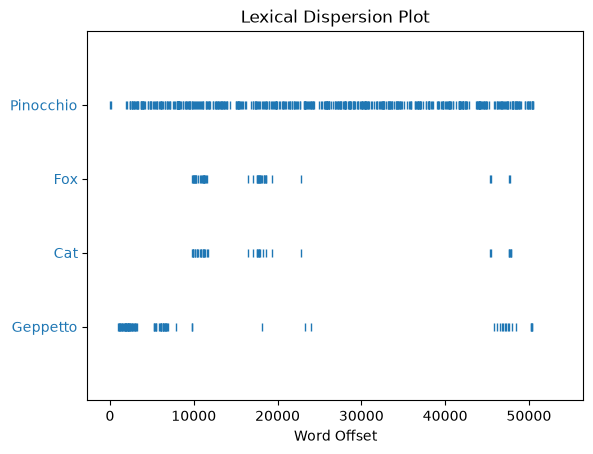

In [27]:
nltk_text.dispersion_plot(["Pinocchio", "Fox", "Cat", "Geppetto"])

In [28]:
len(tokenized_text)

53814

## 🏷️ PoS tagging


In [29]:
nltk.download("averaged_perceptron_tagger_eng")  # a pretrained linear classifier

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/federico/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [30]:
text1 = "I saw a bird."
text2 = "Can you lend me a saw?"

In [31]:
token1 = nltk.word_tokenize(text1)
token2 = nltk.word_tokenize(text2)

In [32]:
token1, token2

(['I', 'saw', 'a', 'bird', '.'], ['Can', 'you', 'lend', 'me', 'a', 'saw', '?'])

In [33]:
nltk.pos_tag(token1)

[('I', 'PRP'), ('saw', 'VBD'), ('a', 'DT'), ('bird', 'NN'), ('.', '.')]

In [34]:
nltk.pos_tag(token2)

[('Can', 'MD'),
 ('you', 'PRP'),
 ('lend', 'VB'),
 ('me', 'PRP'),
 ('a', 'DT'),
 ('saw', 'NN'),
 ('?', '.')]

In [35]:
sentences[42], tokenized_sentences[42]

('He listened for the tiny voice to moan and cry.',
 ['He',
  'listened',
  'for',
  'the',
  'tiny',
  'voice',
  'to',
  'moan',
  'and',
  'cry',
  '.'])

In [36]:
# nltk.pos_tag(sentences[42]) # it doesn't run on strings...

In [37]:
nltk.pos_tag(tokenized_sentences[42])

[('He', 'PRP'),
 ('listened', 'VBD'),
 ('for', 'IN'),
 ('the', 'DT'),
 ('tiny', 'JJ'),
 ('voice', 'NN'),
 ('to', 'TO'),
 ('moan', 'VB'),
 ('and', 'CC'),
 ('cry', 'VB'),
 ('.', '.')]

In [38]:
nltk.pos_tag(nltk.word_tokenize("My name is Andrea"))

[('My', 'PRP$'), ('name', 'NN'), ('is', 'VBZ'), ('Andrea', 'NNP')]

In [39]:
nltk.pos_tag(nltk.word_tokenize("Mi chiamo Andrea"))

[('Mi', 'NNP'), ('chiamo', 'NN'), ('Andrea', 'NNP')]

#### 🇮🇹 PoS tagging with spaCy for Italian


In [40]:
!python -m spacy download it_core_news_sm

Checked 1 package in 3ms
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_sm')


In [41]:
import spacy

# Load the pre-trained Italian model
nlp = spacy.load("it_core_news_sm")

# Process a sentence in Italian
doc = nlp("Mi chiamo Andrea")

# Print tokens and their POS tags
for token in doc:
    print(f"{token.text}: {token.pos_}")

Mi: PRON
chiamo: VERB
Andrea: PROPN


## 🌱 Stemming and lemmatization

A recap from **L03** (word normalization): map the different forms of a word onto one standard form, so that _cars_ and _car_ count as the same thing.

- **Stemming** chops off word endings with rewrite rules and no dictionary: fast, but the result is often not a word (_policy → polic_). The classic one is the Porter stemmer.
- **Lemmatization** maps a word to its **lemma**, the dictionary headword (_am, are, is → be_), using a dictionary (here **WordNet**). It needs the **part of speech**: _better_ is _good_ as an adjective but _well_ as an adverb. NLTK's lemmatizer assumes a noun unless told otherwise; spaCy tags first, so its `token.lemma_` gets it right on its own.


### 🪓 Stemming


In [42]:
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

In [43]:
stemmer.stem("cars")

'car'

In [44]:
stemmer.stem("was")

'wa'

### 📚 Lemmatization


In [45]:
nltk.download("wordnet")  # a lexical database of the English language
# nltk.download('omw-1.4') # Open Multilingual WordNet is a multilingual extension of WordNet.

[nltk_data] Downloading package wordnet to /home/federico/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
from nltk.stem import WordNetLemmatizer

wnl = WordNetLemmatizer()

In [47]:
wnl.lemmatize("dogs")

'dog'

In [48]:
wnl.lemmatize(
    "was"
)  # it needs to know the correct PoS to apply the right lemmatization rule
# by default it assumes a Noun

'wa'

In [49]:
wnl.lemmatize("was", pos="v")

'be'

In [50]:
wnl.lemmatize("better")

'better'

In [51]:
wnl.lemmatize("better", pos="a")  # adjective

'good'

In [52]:
wnl.lemmatize("better", pos="r")  # adverb

'well'

## 👜 Bag of words

To classify a document (L06–L07) we need a vector $x$ of **fixed length**, but documents have different lengths. The simplest answer is the **bag of words**: forget the order of the words and keep only _which_ words occur (or _how often_).

Fix a vocabulary $V = \{w_1, \dots, w_{|V|}\}$, for example all the words seen in the training documents. A document $d$ becomes the vector $x \in \mathbb{R}^{|V|}$ with

$$
x_j = \begin{cases} 1 & \text{if } w_j \text{ occurs in } d \\ 0 & \text{otherwise} \end{cases} \quad \text{(binary)}
\qquad \text{or} \qquad
x_j = C_d(w_j) \quad \text{(counts: how many times } w_j \text{ occurs in } d\text{)} .
$$

For example, with $V$ = (_bad, good, movie, not_), the review _"good movie, not bad"_ becomes $x = [1, 1, 1, 1]$, and so does _"bad movie, not good"_.

The bag of words gives the classifier **one feature per vocabulary word**: tens of thousands of features, most of them 0 in any given document, and no lexicon chosen by hand. The classifier learns which words matter (exercise B2). The price is that word order is lost, as the next cells show.

In Python, the binary bag of words of a single document is simply the `set` of its tokens.


In [53]:
t1 = nltk.word_tokenize("I won, and thus you lose.")
t2 = nltk.word_tokenize("I lose, and thus you won.")

In [54]:
t1, t2, t1 == t2

(['I', 'won', ',', 'and', 'thus', 'you', 'lose', '.'],
 ['I', 'lose', ',', 'and', 'thus', 'you', 'won', '.'],
 False)

The sequence of tokens, of variable length, becomes a set: its binary bag of words.


In [55]:
b1 = set(t1)
b2 = set(t2)

In [56]:
b1, b2, b1 == b2

({',', '.', 'I', 'and', 'lose', 'thus', 'won', 'you'},
 {',', '.', 'I', 'and', 'lose', 'thus', 'won', 'you'},
 True)

🤔 Same bag, opposite meaning: the **order** of the words is lost. Bigrams (next section) keep a little of it.


### 🔗 Word n-grams

A bag of words loses word order. By considering pairs of consecutive
words (bigrams), we preserve some local word-order information.

With a bag of bigrams, we can distinguish the two sentences:


In [57]:
b1 = set(nltk.ngrams(nltk.word_tokenize("I won, and thus, you lose."), 2))
b2 = set(nltk.ngrams(nltk.word_tokenize("I lose, and thus, you won."), 2))

In [58]:
b1, b2, b1 == b2

({(',', 'and'),
  (',', 'you'),
  ('I', 'won'),
  ('and', 'thus'),
  ('lose', '.'),
  ('thus', ','),
  ('won', ','),
  ('you', 'lose')},
 {(',', 'and'),
  (',', 'you'),
  ('I', 'lose'),
  ('and', 'thus'),
  ('lose', ','),
  ('thus', ','),
  ('won', '.'),
  ('you', 'won')},
 False)

### 🔤 Character-level n-grams


In [59]:
b1 = set(nltk.ngrams("rainbow", 3))
b2 = set(nltk.ngrams("rainbaw", 3))

In [60]:
b1, b2

({('a', 'i', 'n'),
  ('b', 'o', 'w'),
  ('i', 'n', 'b'),
  ('n', 'b', 'o'),
  ('r', 'a', 'i')},
 {('a', 'i', 'n'),
  ('b', 'a', 'w'),
  ('i', 'n', 'b'),
  ('n', 'b', 'a'),
  ('r', 'a', 'i')})

In [61]:
b1.intersection(b2)

{('a', 'i', 'n'), ('i', 'n', 'b'), ('r', 'a', 'i')}

## 🎭 Sentiment analysis with VADER

**VADER** (_Valence Aware Dictionary and sEntiment Reasoner_, Hutto & Gilbert, 2014) is a **rule-based** sentiment analyser, built for short social-media texts. Nothing is learned from labelled data: it combines a hand-built lexicon with a few hand-written rules.

1. **The lexicon.** About 7,500 entries (words, but also emoticons like `:-)` and slang like `lol`), each with a **valence** in $[-4, +4]$: the average of the scores given by 10 human raters. For example _great_ = 3.1, _nice_ = 1.8, _sucked_ = −2.0.
2. **The rules** adjust the valence of each word using its context:
   - **negation**: a negation (_not_, _isn't_, _never_, …) among the 3 preceding words multiplies the valence by −0.74, so _not good_ becomes negative;
   - **intensifiers** like _very_ or _extremely_ add about 0.3 to the valence, while _kind of_ or _slightly_ remove it;
   - **CAPITALS** (_GREAT_ in a lowercase sentence) and **exclamation marks** amplify;
   - **but**: the words before it count half, the words after it count 1.5 times.
3. **The scores.** The adjusted valences are summed into $s$, and squashed into $(-1, 1)$: $\;\text{compound} = s / \sqrt{s^2 + 15}$. The scores `neg`, `neu` and `pos` are the proportions of the text that are negative, neutral and positive. A common convention: positive if compound ≥ 0.05, negative if compound ≤ −0.05.

In exercise B2 we compare VADER with classifiers that **learn** from labelled reviews.


In [62]:
# import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/federico/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [63]:
# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Access the VADER lexicon
vader_lexicon = sia.lexicon

In [64]:
type(vader_lexicon), len(vader_lexicon)

(dict, 7502)

In [65]:
list(vader_lexicon.items())

[('$:', -1.5),
 ('%)', -0.4),
 ('%-)', -1.5),
 ('&-:', -0.4),
 ('&:', -0.7),
 ("( '}{' )", 1.6),
 ('(%', -0.9),
 ("('-:", 2.2),
 ("(':", 2.3),
 ('((-:', 2.1),
 ('(*', 1.1),
 ('(-%', -0.7),
 ('(-*', 1.3),
 ('(-:', 1.6),
 ('(-:0', 2.8),
 ('(-:<', -0.4),
 ('(-:o', 1.5),
 ('(-:O', 1.5),
 ('(-:{', -0.1),
 ('(-:|>*', 1.9),
 ('(-;', 1.3),
 ('(-;|', 2.1),
 ('(8', 2.6),
 ('(:', 2.2),
 ('(:0', 2.4),
 ('(:<', -0.2),
 ('(:o', 2.5),
 ('(:O', 2.5),
 ('(;', 1.1),
 ('(;<', 0.3),
 ('(=', 2.2),
 ('(?:', 2.1),
 ('(^:', 1.5),
 ('(^;', 1.5),
 ('(^;0', 2.0),
 ('(^;o', 1.9),
 ('(o:', 1.6),
 (")':", -2.0),
 (")-':", -2.1),
 (')-:', -2.1),
 (')-:<', -2.2),
 (')-:{', -2.1),
 ('):', -1.8),
 ('):<', -1.9),
 ('):{', -2.3),
 (');<', -2.6),
 ('*)', 0.6),
 ('*-)', 0.3),
 ('*-:', 2.1),
 ('*-;', 2.4),
 ('*:', 1.9),
 ('*<|:-)', 1.6),
 ('*\\0/*', 2.3),
 ('*^:', 1.6),
 (',-:', 1.2),
 ("---'-;-{@", 2.3),
 ('--<--<@', 2.2),
 ('.-:', -1.2),
 ('..###-:', -1.7),
 ('..###:', -1.9),
 ('/-:', -1.3),
 ('/:', -1.3),
 ('/:<', -1.4),

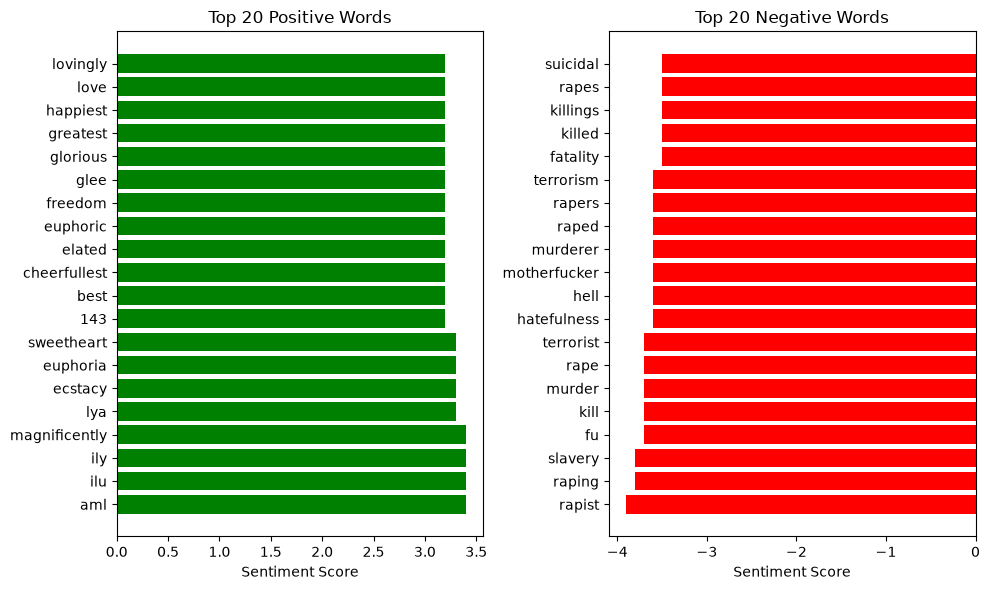

In [66]:
# Extract positive and negative words based on sentiment score
positive_words = {word: score for word, score in vader_lexicon.items() if score > 0}
negative_words = {word: score for word, score in vader_lexicon.items() if score < 0}

# Sort by sentiment score
positive_words_sorted = sorted(
    positive_words.items(), key=lambda x: x[1], reverse=True
)[:20]
negative_words_sorted = sorted(negative_words.items(), key=lambda x: x[1])[:20]

# Create bar plots for the most positive and negative words
plt.figure(figsize=(10, 6))

# Plot positive words
plt.subplot(1, 2, 1)
positive_words_sorted = dict(positive_words_sorted)  # Convert to dict for plotting
plt.barh(
    list(positive_words_sorted.keys()),
    list(positive_words_sorted.values()),
    color="green",
)
plt.title("Top 20 Positive Words")
plt.xlabel("Sentiment Score")

# Plot negative words
plt.subplot(1, 2, 2)
negative_words_sorted = dict(negative_words_sorted)  # Convert to dict for plotting
plt.barh(
    list(negative_words_sorted.keys()),
    list(negative_words_sorted.values()),
    color="red",
)
plt.title("Top 20 Negative Words")
plt.xlabel("Sentiment Score")

# Show the plots
plt.tight_layout()
plt.show()


In [67]:
# Sample text
text = "The new movie, called Pinocchio, was absolutely fantastic! The plot was gripping, and the actors gave an outstanding performance. However, the ending was a bit too predictable, which left me very disappointed."

In [68]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [69]:
# Get sentiment score
sentiment_score = sia.polarity_scores(text)

print("NLTK Sentiment Analysis Result:", sentiment_score)

NLTK Sentiment Analysis Result: {'neg': 0.086, 'neu': 0.707, 'pos': 0.207, 'compound': 0.6996}


This means that 8.6% of text is negative, 70.7% of text is neutral, and 20.7% of text is positive. Compound is an overall score of the sentiment ranging in the interval (-1,1).


In [70]:
# adjust compound to get a sort of probability of positive sentiment
prob_positive = (sentiment_score["compound"] + 1) / 2  # compound varies in (-1,1)
print("Overall probability of positive sentiment:", prob_positive)

Overall probability of positive sentiment: 0.8498


In [71]:
text2 = "The new movie, called The Hell of Rapists, was absolutely fantastic!"
sia = SentimentIntensityAnalyzer()
sentiment_score2 = sia.polarity_scores(text2)
print("NLTK Sentiment Analysis Result on sentence 2:", sentiment_score2)
prob_positive2 = (sentiment_score2["compound"] + 1) / 2  # compound varies in (-1,1)
print("Overall probability of positive sentiment for sentence 2:", prob_positive2)

NLTK Sentiment Analysis Result on sentence 2: {'neg': 0.436, 'neu': 0.379, 'pos': 0.185, 'compound': -0.743}
Overall probability of positive sentiment for sentence 2: 0.1285


## 🧽 Try to remove stopwords. Does sentiment change?


In [72]:
# Remove stopwords
stop_words = set(stopwords.words("english"))
# Tokenize the text into words
tokens = nltk.word_tokenize(text)
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]

In [73]:
filtered_tokens

['new',
 'movie',
 ',',
 'called',
 'Pinocchio',
 ',',
 'absolutely',
 'fantastic',
 '!',
 'plot',
 'gripping',
 ',',
 'actors',
 'gave',
 'outstanding',
 'performance',
 '.',
 'However',
 ',',
 'ending',
 'bit',
 'predictable',
 ',',
 'left',
 'disappointed',
 '.']

In [74]:
# Join the filtered tokens back into a string
filtered_text = " ".join(filtered_tokens)

In [75]:
filtered_text

'new movie , called Pinocchio , absolutely fantastic ! plot gripping , actors gave outstanding performance . However , ending bit predictable , left disappointed .'

In [76]:
filtered_sent_score = sia.polarity_scores(filtered_text)
print("NLTK Sentiment Analysis Result:", filtered_sent_score)

NLTK Sentiment Analysis Result: {'neg': 0.118, 'neu': 0.571, 'pos': 0.311, 'compound': 0.7257}


In [77]:
print(
    "Overall probability of positive sentiment:",
    (filtered_sent_score["compound"] + 1) / 2,
)

Overall probability of positive sentiment: 0.86285


# 🤗 Sentiment analysis with Hugging Face

[Hugging Face](https://huggingface.co) is a platform where researchers and companies share **pretrained models**, together with the Python library `transformers` to use them. The `pipeline` function hides all the details: give it a task (here `"sentiment-analysis"`) and a model name, and it downloads the model and turns raw text into a label with a confidence score.

Unlike VADER, this transformer model **learned** sentiment from examples: sentences from movie reviews labelled positive or negative (the SST-2 dataset). Here we use it as a black box; several lectures later in the course are dedicated to transformers.


In [78]:
# !pip install transformers   # already installed on Colab

In [79]:
from transformers import pipeline

In [ ]:
# Use Hugging Face's pipeline for sentiment analysis (we name the model explicitly)
sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [81]:
# Sample text
text = "The new movie, called Pinocchio, was absolutely fantastic! The plot was gripping, and the actors gave an outstanding performance. However, the ending was a bit too predictable, which left me very disappointed."

In [82]:
# Perform sentiment analysis using Hugging Face pipeline
sentiment_result = sentiment_pipeline(text)  # , return_all_scores=True)

print("Hugging Face Sentiment Analysis Result:")
print(sentiment_result)

Hugging Face Sentiment Analysis Result:
[{'label': 'NEGATIVE', 'score': 0.9432030916213989}]


# 🚀 spaCy

[spaCy](https://spacy.io) is an NLP library built for **production**: it is fast (written in Cython) and comes with pretrained statistical models, small neural networks, for many languages, Italian included. Where NLTK is a toolbox, spaCy is a **pipeline**: you load a model once, give it a raw string, and get back a `Doc` object with all the analyses already computed.

```
raw text ──► nlp = spacy.load("en_core_web_sm") ──► doc
             tokenizer → tagger → parser → lemmatizer → NER
```

|        | NLTK                                                   | spaCy                                                                          |
| ------ | ------------------------------------------------------ | ------------------------------------------------------------------------------ |
| input  | lists of tokens                                        | raw text                                                                       |
| style  | separate functions, you choose and combine them        | one pipeline, one call                                                         |
| models | classic algorithms: perceptron, maximum entropy, rules | pretrained neural networks (`en_core_web_sm`, `it_core_news_sm`, …)            |
| output | lists, sets, trees                                     | a `Doc`: tokens with attributes (`.lemma_`, `.pos_`, `.dep_`, `.ent_type_`, …) |

`_sm` means _small_: a compact model that runs fast on a laptop. Larger and more accurate ones exist (`_md`, `_lg`, and `_trf`, based on a transformer).


In [83]:
# spaCy and the small English model are preinstalled on Colab; elsewhere:
# !pip install spacy
!python -m spacy download en_core_web_sm

Checked 1 package in 3ms
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 📄 The spaCy `doc` object


#### Initialize a pipeline

English tokenizer, tagger, parser and NER


In [ ]:
import pandas as pd
import spacy

# Load spaCy's English model (downloaded if missing)
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

#### Processing of a new text


In [85]:
text = """Game of Thrones is an American fantasy drama television series created by David Benioff and D. B. Weiss for HBO. It is an adaptation of A Song of Ice and Fire, a series of fantasy novels by George R. R. Martin, the first of which is A Game of Thrones. The show was shot in the United Kingdom, Canada, Croatia, Iceland, Malta, Morocco, and Spain. It premiered on HBO in the United States on April 17, 2011, and concluded on May 19, 2019, with 73 episodes broadcast over eight seasons.

Set on the fictional continents of Westeros and Essos, Game of Thrones has a large ensemble cast and follows several story arcs throughout the course of the show. The first major arc concerns the Iron Throne of the Seven Kingdoms of Westeros through a web of political conflicts among the noble families either vying to claim the throne or fighting for independence from whoever sits on it. A second focuses on the last descendant of the realm's deposed ruling dynasty, who has been exiled to Essos and is plotting to return and reclaim the throne. The third follows the Night's Watch, a military order defending the realm against threats from beyond Westeros's northern border.

Game of Thrones attracted a record viewership on HBO and has a broad, active, and international fan base. Critics have praised the series for its acting, complex characters, story, scope, and production values, although its frequent use of nudity and violence (including sexual violence) has been subject to criticism. The final season received significant critical backlash for its reduced length and creative decisions, with many considering it a disappointing conclusion. The series received 59 Primetime Emmy Awards, the most by a drama series, including Outstanding Drama Series in 2015, 2016, 2018 and 2019. Its other awards and nominations include three Hugo Awards for Best Dramatic Presentation, a Peabody Award, and five nominations for the Golden Globe Award for Best Television Series – Drama. Many critics and publications have named the show as one of the best television series of all time.

A prequel series, House of the Dragon, premiered on HBO in 2022.
"""


In [86]:
doc = nlp(text)

In [87]:
doc

Game of Thrones is an American fantasy drama television series created by David Benioff and D. B. Weiss for HBO. It is an adaptation of A Song of Ice and Fire, a series of fantasy novels by George R. R. Martin, the first of which is A Game of Thrones. The show was shot in the United Kingdom, Canada, Croatia, Iceland, Malta, Morocco, and Spain. It premiered on HBO in the United States on April 17, 2011, and concluded on May 19, 2019, with 73 episodes broadcast over eight seasons.

Set on the fictional continents of Westeros and Essos, Game of Thrones has a large ensemble cast and follows several story arcs throughout the course of the show. The first major arc concerns the Iron Throne of the Seven Kingdoms of Westeros through a web of political conflicts among the noble families either vying to claim the throne or fighting for independence from whoever sits on it. A second focuses on the last descendant of the realm's deposed ruling dynasty, who has been exiled to Essos and is plotting 

In [88]:
len(doc), doc[2], doc[42]

(412, Thrones, Martin)

The object `doc` comes naturally with a lot of properties


#### Analyze sentences


In [ ]:
i = 0
for sentence in doc.sents:
    print(i, sentence.text)
    i += 1  # noqa: SIM113


0 Game of Thrones is an American fantasy drama television series created by David Benioff and D. B. Weiss for HBO.
1 It is an adaptation of A Song of Ice and Fire, a series of fantasy novels by George R. R. Martin, the first of which is A Game of Thrones.
2 The show was shot in the United Kingdom, Canada, Croatia, Iceland, Malta, Morocco, and Spain.
3 It premiered on HBO in the United States on April 17, 2011, and concluded on May 19, 2019, with 73 episodes broadcast over eight seasons.


4 Set on the fictional continents of Westeros and Essos, Game of Thrones has a large ensemble cast and follows several story arcs throughout the course of the show.
5 The first major arc concerns the Iron Throne of the Seven Kingdoms of Westeros through a web of political conflicts among the noble families either vying to claim the throne or fighting for independence from whoever sits on it.
6 A second focuses on the last descendant of the realm's deposed ruling dynasty, who has been exiled to Essos a

#### tokens and morphological information


In [90]:
for token in doc:
    row = [
        token.text,
        token.lemma_,  # lemmatization
        token.pos_,  # pos tagging
        token.tag_,  # more fine-grained pos tagging
        token.dep_,  # syntactic dependency relation
        token.shape_,  # orthographic wordshape
        token.is_alpha,  # alphabetic
        token.is_stop,  # stopword
    ]
    print(row)

['Game', 'Game', 'PROPN', 'NNP', 'nsubj', 'Xxxx', True, False]
['of', 'of', 'ADP', 'IN', 'prep', 'xx', True, True]
['Thrones', 'Thrones', 'PROPN', 'NNP', 'pobj', 'Xxxxx', True, False]
['is', 'be', 'AUX', 'VBZ', 'ROOT', 'xx', True, True]
['an', 'an', 'DET', 'DT', 'det', 'xx', True, True]
['American', 'american', 'ADJ', 'JJ', 'amod', 'Xxxxx', True, False]
['fantasy', 'fantasy', 'NOUN', 'NN', 'compound', 'xxxx', True, False]
['drama', 'drama', 'NOUN', 'NN', 'compound', 'xxxx', True, False]
['television', 'television', 'NOUN', 'NN', 'compound', 'xxxx', True, False]
['series', 'series', 'NOUN', 'NN', 'attr', 'xxxx', True, False]
['created', 'create', 'VERB', 'VBN', 'acl', 'xxxx', True, False]
['by', 'by', 'ADP', 'IN', 'agent', 'xx', True, True]
['David', 'David', 'PROPN', 'NNP', 'compound', 'Xxxxx', True, False]
['Benioff', 'Benioff', 'PROPN', 'NNP', 'pobj', 'Xxxxx', True, False]
['and', 'and', 'CCONJ', 'CC', 'cc', 'xxx', True, True]
['D.', 'D.', 'PROPN', 'NNP', 'compound', 'X.', False, Fal

#### Add tokens and linguistic info into a DataFrame


In [91]:
tokens = []
df = pd.DataFrame(
    columns=["text", "lemma", "pos_", "tag_", "dep_", "shape_", "is_alpha", "is_stop"]
)

for token in doc:
    row = {
        "text": token.text,
        "lemma": token.lemma_,
        "pos_": token.pos_,
        "tag_": token.tag_,
        "dep_": token.dep_,
        "shape_": token.shape_,
        "is_stop": token.is_stop,
    }
    tokens.append(row)
df = pd.DataFrame(tokens)
df

,text,lemma,pos_,tag_,dep_,shape_,is_stop
0,Game,Game,PROPN,NNP,nsubj,Xxxx,False
1,of,of,ADP,IN,prep,xx,True
2,Thrones,Thrones,PROPN,NNP,pobj,Xxxxx,False
3,is,be,AUX,VBZ,ROOT,xx,True
4,an,an,DET,DT,det,xx,True
...,...,...,...,...,...,...,...
407,HBO,HBO,PROPN,NNP,pobj,XXX,False
408,in,in,ADP,IN,prep,xx,True
409,2022,2022,NUM,CD,pobj,dddd,False
410,.,.,PUNCT,.,punct,.,False


#### 🌳 Visualize the dependency parse

A **syntactic parse** describes the grammatical structure of a sentence: who does what to whom. spaCy produces a **dependency parse**: every word is attached to one other word, its **head**, by an arc labelled with the grammatical relation between them. The main verb is the **ROOT** and has no head, so the arcs form a tree.

In _Pinocchio sold his book to buy a ticket._:

- _sold_ is the ROOT;
- _Pinocchio_ depends on _sold_ as `nsubj` (nominal subject), _book_ depends on _sold_ as `dobj` (direct object);
- _his_ depends on _book_ as `poss` (possessor); _buy_ depends on _sold_ as `advcl` (adverbial clause: why he sold it).

These are the labels of the `dep_` column above; `token.head` gives the head. In the drawing, each arrow goes from the head to the dependent.

The other classic representation is the **constituency** (phrase-structure) tree, which groups words into nested phrases: [S [NP Pinocchio] [VP sold [NP his book] …]]. If you are interested, J&M book (chapters 19-20) covers both kinds of parsing.


In [92]:
from spacy import displacy
from IPython.display import display, HTML

pinocchio_doc = nlp("Pinocchio sold his book to buy a ticket.")
for token in pinocchio_doc:
    print(f"{token.text:10s} --{token.dep_:>6s}-->  {token.head.text}")
display(HTML(displacy.render(pinocchio_doc, style="dep")))

Pinocchio  -- nsubj-->  sold
sold       --  ROOT-->  sold
his        --  poss-->  book
book       --  dobj-->  sold
to         --   aux-->  buy
buy        -- advcl-->  sold
a          --   det-->  ticket
ticket     --  dobj-->  buy
.          -- punct-->  sold


<IPython.core.display.HTML object>

In [93]:
from spacy import displacy
from IPython.display import display, HTML

first_sentence = next(doc.sents)
html = displacy.render(first_sentence, style="dep")
display(HTML(html))

<IPython.core.display.HTML object>

#### 🧱 Analyze noun phrases

A **noun phrase** is a noun together with the words that describe it: determiners, adjectives, other nouns (_an American fantasy drama television series_). spaCy finds them with `doc.noun_chunks`, using the dependency parse above: each chunk is a noun plus the words that depend on it.

Note that these are _base_ noun phrases, flat and without nested phrases: _Game of Thrones_ comes out as two chunks, _Game_ and _Thrones_. They are useful to extract the "things" a text talks about.


In [94]:
print("Noun phrases:", [chunk.text for chunk in doc.noun_chunks])
# each chunk is a noun with its determiners, adjectives and noun modifiers

Noun phrases: ['Game', 'Thrones', 'an American fantasy drama television series', 'David Benioff', 'D. B. Weiss', 'HBO', 'It', 'an adaptation', 'A Song', 'Ice', 'Fire', 'a series', 'fantasy novels', 'George R. R. Martin', 'which', 'A Game', 'Thrones', 'The show', 'the United Kingdom', 'Canada', 'Croatia', 'Iceland', 'Malta', 'Morocco', 'Spain', 'It', 'HBO', 'the United States', 'April', 'May', '73 episodes', 'eight seasons', 'the fictional continents', 'Westeros', 'Essos', 'Game', 'Thrones', 'a large ensemble cast', 'several story arcs', 'the course', 'the show', 'The first major arc', 'the Iron Throne', 'the Seven Kingdoms', 'Westeros', 'a web', 'political conflicts', 'the noble families', 'the throne', 'independence', 'whoever', 'it', 'the last descendant', "the realm's deposed ruling dynasty", 'who', 'Essos', 'the throne', 'The third', "the Night's Watch", 'a military order', 'the realm', 'threats', "Westeros's northern border", 'Game', 'Thrones', 'a record viewership', 'HBO', 'a bro

#### 🏃 Filter verbs


In [95]:
print("Verbs:", [token.lemma_ for token in doc if token.pos_ == "VERB"])

Verbs: ['create', 'shoot', 'premier', 'conclude', 'broadcast', 'Set', 'have', 'follow', 'concern', 'vie', 'claim', 'fight', 'sit', 'focus', 'depose', 'exile', 'plot', 'return', 'reclaim', 'follow', 'defend', 'attract', 'have', 'praise', 'act', 'include', 'receive', 'reduce', 'consider', 'receive', 'include', 'include', 'name', 'premier']


## 🕵️ NER with spaCy

**Named entity recognition** (NER, L08) finds the spans of text that are proper names and labels their type: person, organization, place, date, money, … spaCy does it as part of the same pipeline: the entities are already in `doc.ents`, each with its text and its label (`ent.label_`). `spacy.explain(label)` tells you what a label means.


In [96]:
# Define the text
text = """Apple Inc. was founded by Steve Jobs, Steve Wozniak, and Ronald Wayne
in April 1976 in Cupertino, California. The company is known for its iPhones,
iPads, and Mac computers. In 2023, Apple became the first company to reach a
market capitalization of $3 trillion."""

In [97]:
# Process the text
doc = nlp(text)

# Extract and display named entities
print(f"{'Entity':<20} {'Label':<10} {'Explanation'}")
print("=" * 50)

for ent in doc.ents:  # doc.ents contains all detected entities
    print(f"{ent.text:<20} {ent.label_:<10} {spacy.explain(ent.label_)}")


Entity               Label      Explanation
Apple Inc.           ORG        Companies, agencies, institutions, etc.
Steve Jobs           PERSON     People, including fictional
Steve Wozniak        PERSON     People, including fictional
Ronald Wayne         PERSON     People, including fictional
April 1976           DATE       Absolute or relative dates or periods
Cupertino            GPE        Countries, cities, states
California           GPE        Countries, cities, states
iPhones              ORG        Companies, agencies, institutions, etc.
Mac                  ORG        Companies, agencies, institutions, etc.
2023                 DATE       Absolute or relative dates or periods
Apple                ORG        Companies, agencies, institutions, etc.
first                ORDINAL    "first", "second", etc.
$3 trillion          MONEY      Monetary values, including unit


#### 🖍️ Visualize entities


In [98]:
from IPython.display import display, HTML

html = displacy.render(doc, style="ent")
display(HTML(html))

<IPython.core.display.HTML object>

Both libraries use **statistical models** learned from annotated corpora. The difference is the kind of model: spaCy uses small neural networks over learned word representations, while NLTK's tagger and NE chunker are classic linear classifiers (an averaged perceptron and a maximum-entropy classifier) over hand-designed features.


## 🔁 Same NER example with NLTK


In [99]:
nltk.download(
    "words"
)  # a word list; the NE chunker uses "is it one of the 850 words of Basic English?" as one of its features
nltk.download(
    "maxent_ne_chunker_tab"
)  # the trained NE chunker: a maximum-entropy classifier (= multinomial logistic regression, L06-L07)

[nltk_data] Downloading package words to /home/federico/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /home/federico/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


True

In [ ]:
from nltk.chunk import ne_chunk
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize


In [101]:
# Tokenize the text
words = word_tokenize(text)

# Part-of-Speech (POS) Tagging
pos_tags = pos_tag(words)

# Named Entity Recognition (NER)
named_entities = ne_chunk(pos_tags)  # you have to postag before...

# Print the named entities
print(named_entities)

(S
  (PERSON Apple/NNP)
  (ORGANIZATION Inc./NNP)
  was/VBD
  founded/VBN
  by/IN
  (PERSON Steve/NNP Jobs/NNP)
  ,/,
  (PERSON Steve/NNP Wozniak/NNP)
  ,/,
  and/CC
  (PERSON Ronald/NNP Wayne/NNP)
  in/IN
  April/NNP
  1976/CD
  in/IN
  (GPE Cupertino/NNP)
  ,/,
  (GPE California/NNP)
  ./.
  The/DT
  company/NN
  is/VBZ
  known/VBN
  for/IN
  its/PRP$
  (ORGANIZATION iPhones/NNS)
  ,/,
  (ORGANIZATION iPads/NNS)
  ,/,
  and/CC
  (ORGANIZATION Mac/NNP)
  computers/NNS
  ./.
  In/IN
  2023/CD
  ,/,
  (PERSON Apple/NNP)
  became/VBD
  the/DT
  first/JJ
  company/NN
  to/TO
  reach/VB
  a/DT
  market/NN
  capitalization/NN
  of/IN
  $/$
  3/CD
  trillion/CD
  ./.)


In [102]:
# Function to extract named entities
def extract_entities(tree):
    entities = []
    for subtree in tree:
        if isinstance(subtree, nltk.Tree):  # Identifies named entities
            entity_name = " ".join(
                word for word, tag in subtree.leaves()
            )  # Join multi-word entities
            entity_type = subtree.label()  # Get entity type (e.g., PERSON, GPE)
            entities.append((entity_name, entity_type))
    return entities


# Extract entities
entities = extract_entities(named_entities)

# Display in formatted output
print(f"{'Entity':<20} {'Label':<15}")
print("=" * 35)
for entity, label in entities:
    print(f"{entity:<20} {label:<15}")

Entity               Label          
Apple                PERSON         
Inc.                 ORGANIZATION   
Steve Jobs           PERSON         
Steve Wozniak        PERSON         
Ronald Wayne         PERSON         
Cupertino            GPE            
California           GPE            
iPhones              ORGANIZATION   
iPads                ORGANIZATION   
Mac                  ORGANIZATION   
Apple                PERSON         


# 🛠️ NLTK (Natural Language Toolkit)

✅ Pros:

- Rich collection of text processing libraries (tokenization, parsing, stemming, etc.)

- Many linguistic datasets and corpora available

- More control over NLP workflows

- Good for teaching and research

❌ Cons:

- Slower than SpaCy

- Requires more manual coding for tasks like Named Entity Recognition (NER)

# 🚀 spaCy

✅ Pros:

- Optimized for speed and efficiency

- Pre-trained models for multiple languages

- Easy-to-use API

- Better for Named Entity Recognition (NER) and dependency parsing

- Integrates well with deep learning frameworks (TensorFlow, PyTorch)

❌ Cons:

- Fewer linguistic resources than NLTK

- Less flexibility for custom tokenization or parsing


# ⚖️ NLTK or spaCy?

Choose NLTK if you need detailed text analysis, want to work with corpora, or prefer a more academic approach.

Choose SpaCy if you need fast, production-ready NLP with pre-trained models and deep learning support.

If you're working on large-scale NLP applications, SpaCy is usually the better choice. If you're exploring NLP for research or educational purposes, NLTK might be more useful.


---


# 🏋️ Exercises (not graded, just for fun and understanding)

Time to play. Every exercise has a **TODO cell** (your code) followed by a **🧪 check cell** that tells you whether you got it right:

- ✅ correct · ❌ something is off (the message tells you what) · ⏳ not implemented yet

Plain Python is enough for every exercise: lists, dicts, sets, loops and comprehensions. You do not need to import anything.

### 🧑‍💻 How to work on an exercise

1. Read the box **✏️ What you have to write**: it gives the name of the function, what goes in (**input**), what must come out (**output**), sometimes a hint, and a small **worked example** with the expected result.
2. Write your code in the cell marked `# ✏️ YOUR CODE HERE`, replacing `return None`, and run that cell.
3. Try your function by hand on the worked example, e.g. in a new cell: `print(ambiguity_stats([("the", "DT"), ("back", "NN"), ("back", "RB"), ("the", "DT"), ("dog", "NN")]))`.
4. Run the **🧪 check** cell right below. If you get ❌, read the message: it says which input went wrong, what you returned and what was expected. If you get ⏳, your function still returns `None`.

The exercises use the libraries seen above on topics of the last lectures: **Part A** on part-of-speech tagging and named entity recognition (J&M Chapter 18, L08), **Part B** on text classification with logistic regression (J&M Chapter 4, L06–L07). Each part starts with its own setup cell, so you can start from either one.

### 🧭 Suggested path for the lab session

Start from Part A, then Part B:

**A1 → A2 → A3 → A4 → A5**

**B1 → B2 → B3**

|     | Exercise                                             | Idea                                                 |
| --- | ---------------------------------------------------- | ---------------------------------------------------- |
| A1  | Six parts of speech for _back_                       | fool the taggers                                     |
| A2  | How ambiguous is English?                            | Fig. 18.4 on a real treebank                         |
| A3  | The most-frequent-tag baseline                       | the 92% every tagger must beat                       |
| A4  | Span-level evaluation of NER: spaCy vs NLTK          | why token accuracy lies (§18.6)                      |
| A5  | spaCy reads Dante                                    | the domain problem                                   |
| B1  | The features of Fig. 4.2, with a real lexicon        | feature extraction = tokenizer + lexicon + rules     |
| B2  | Precision, recall, F1 and four sentiment classifiers | rules vs 6 features vs bag of words vs a transformer |
| B3  | Is the difference statistically significant?         | the paired bootstrap test of L07                     |

> 🎲 Some exercises contain a **Bet**: write your prediction down _before_ running the code.


# 🧬 Part A · Sequence labelling: PoS tagging and NER (J&M Ch. 18)

NLTK ships a 10% sample of the **Penn Treebank** Wall Street Journal corpus (`nltk.corpus.treebank`, ~3,900 sentences, ~100k tokens) with gold PTB tags. We remove the `-NONE-` tokens (empty elements of the syntactic annotation, not real words) and split the sentences 80/20 into train and test.


In [ ]:
# 🧪 Setup for Part A (just run it)
import importlib
import math
import re
from collections import (
    Counter,
    defaultdict,
)  # used by the check cells, not needed in your code

import nltk
import numpy as np

for _pkg in [
    "punkt_tab",
    "treebank",
    "averaged_perceptron_tagger_eng",
    "maxent_ne_chunker_tab",
    "words",
]:
    nltk.download(_pkg, quiet=True)

import spacy
from nltk.corpus import treebank
from spacy.tokens import Doc

try:
    nlp_en = spacy.load("en_core_web_sm")
except OSError:
    spacy.cli.download("en_core_web_sm")
    importlib.invalidate_caches()
    nlp_en = spacy.load("en_core_web_sm")


def _ok(msg):
    print("✅", msg)


def _fail(msg):
    print("❌", msg)


def _todo(name):
    print(f"⏳ {name}: not implemented yet (your function returned None).")


def _err(e):
    _fail(f"your code raised {type(e).__name__}: {e}")


def _close(a, b, tol=1e-6):
    return abs(float(a) - float(b)) <= tol * max(1.0, abs(float(a)), abs(float(b)))


tb_sents = [[(w, t) for (w, t) in s if t != "-NONE-"] for s in treebank.tagged_sents()]
_cut = int(0.8 * len(tb_sents))
tb_train, tb_test = tb_sents[:_cut], tb_sents[_cut:]
print(
    f"{len(tb_train)} training and {len(tb_test)} test sentences; {sum(map(len, tb_sents))} tokens"
)
print(tb_train[0])

3131 training and 783 test sentences; 94084 tokens
[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')]


## 🔙 A1. Six parts of speech for _back_

The lecture showed one word with six PTB tags. Let's see how NLTK's averaged perceptron and spaCy's `en_core_web_sm` do on them. We give spaCy NLTK's tokens (`Doc(nlp.vocab, words=...)`), so that the two taggers see exactly the same tokens.


In [104]:
# ▶️ Given
BACK = [
    ("earnings growth took a back seat", "JJ"),
    ("a small building in the back", "NN"),
    ("a clear majority of senators back the bill", "VBP"),
    ("Dave began to back toward the door", "VB"),
    ("enable the country to buy back debt", "RP"),
    ("I was twenty-one back then", "RB"),
]


def two_taggers(sentence):
    words = nltk.word_tokenize(sentence)
    return (
        words,
        [t for _, t in nltk.pos_tag(words)],
        [tok.tag_ for tok in nlp_en(Doc(nlp_en.vocab, words=words))],
    )


print(f"{'gold':5s} {'NLTK':5s} {'spaCy':5s}  sentence")
for s, gold in BACK:
    words, nl, sp = two_taggers(s)
    i = words.index("back")
    print(f"{gold:5s} {nl[i]:5s} {sp[i]:5s}  {s}")

gold  NLTK  spaCy  sentence
JJ    JJ    JJ     earnings growth took a back seat
NN    NN    NN     a small building in the back
VBP   VBP   VBP    a clear majority of senators back the bill
VB    VB    VB     Dave began to back toward the door
RP    RP    RB     enable the country to buy back debt
RB    RB    RB     I was twenty-one back then


Both taggers are good!

#### ✏️ What you have to write: the list `my_sentences`

- A Python list of **at least 3 strings**, each one an English sentence: `my_sentences = ["...", "...", "..."]`.
- The check tags every sentence with both taggers and prints 🔀 with the tokens where they disagree, or 🟰 if they agree on every token. You need at least 3 🔀.
- Then, for each 🔀, look up the two tags in the [Penn Treebank tagset](https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html) and decide who is right (sometimes neither!).

Ideas: words like _that, down, put, set, round, still_; ambiguous pronouns (_I saw her duck._); garden-path sentences (_The old man the boat._); newspaper headlines (_Police help dog bite victim._).


In [133]:
# ✏️ YOUR CODE HERE
my_sentences = [
    "I have your back",
    "don't look back",
    "back in the day",
]

In [134]:
# 🧪 Check A1
if isinstance(my_sentences, str) or len(my_sentences) < 3:
    print("⏳ A1: put at least three sentences (strings) in the list my_sentences.")
else:
    n_dis = 0
    for s in my_sentences:
        try:
            words, nl, sp = two_taggers(s)
        except Exception as e:
            _err(e)
            continue
        diff = [
            f"{w}: NLTK {a} / spaCy {b}" for w, a, b in zip(words, nl, sp) if a != b
        ]
        n_dis += bool(diff)
        print(
            ("🔀 " if diff else "🟰 ")
            + s
            + ("\n      " + "; ".join(diff) if diff else "")
        )
    (_ok if n_dis >= 3 else _fail)(
        f"{n_dis} of your sentences make the taggers disagree"
        + ("" if n_dis >= 3 else " (need 3)")
    )

🟰 I have your back
🔀 don't look back
      do: NLTK VBP / spaCy VB
🟰 back in the day
❌ 1 of your sentences make the taggers disagree (need 3)


## 🌀 A2. How ambiguous is English?

Fig. 18.4 of the book: on the full WSJ, 14% of the word **types** are ambiguous (they occur with 2+ tags), but they cover 55% of the word **tokens** (instances).

#### ✏️ What you have to write: `ambiguity_stats(tagged_words)`

- **Input:** `tagged_words`, a list of `(word, tag)` pairs, one per token, for example `[("the", "DT"), ("back", "NN"), ("back", "RB")]`. The check passes all the tokens of the treebank in one list.
- **Output:** a tuple of two fractions between 0 and 1, `(frac_ambiguous_types, frac_ambiguous_tokens)`:
  - a word **type** is ambiguous if it appears with 2 or more different tags; `frac_ambiguous_types` = number of ambiguous types / number of types;
  - `frac_ambiguous_tokens` = number of pairs whose word is ambiguous / total number of pairs.
- Words are case-sensitive: _The_ and _the_ are different types.

_Hint:_ a dict that maps each word to the **set** of its tags.

**Worked example:** `ambiguity_stats([("the", "DT"), ("back", "NN"), ("back", "RB"), ("the", "DT"), ("dog", "NN")])`

- result: `(0.333, 0.4)`: 1 ambiguous type (_back_) out of 3, and 2 of the 5 pairs are _back_

> 🎲 **Bet:** on our 10% sample, will the two percentages be higher or lower than in the book?


In [ ]:
# ✏️ YOUR CODE HERE
def ambiguity_stats(tagged_words):
    """Input: a list of (word, tag) pairs. Output: (frac_ambiguous_types, frac_ambiguous_tokens)."""
    return None

In [136]:
# 🧪 Check A2
try:
    _toy = [("the", "DT"), ("back", "NN"), ("back", "RB"), ("the", "DT"), ("dog", "NN")]
    if ambiguity_stats(_toy) is None:
        _todo("A2")
    else:
        ft, fk = ambiguity_stats(_toy)
        if ft > 1 or fk > 1:
            _fail(
                f"got ({ft}, {fk}): return fractions between 0 and 1, not percentages"
            )
        elif _close(ft, 0.4) and _close(fk, 1 / 3):
            _fail(
                "you returned (tokens, types): the order is (frac_ambiguous_types, frac_ambiguous_tokens)"
            )
        elif not (_close(ft, 1 / 3) and _close(fk, 0.4)):
            _fail(
                f"toy example {_toy}: got ({float(ft):.3f}, {float(fk):.3f}), expected (0.333, 0.400): "
                "1 of the 3 types (back) is ambiguous, and it covers 2 of the 5 tokens"
            )
        else:
            ft, fk = ambiguity_stats([p for s in tb_sents for p in s])
            _ok(
                f"treebank sample: {ft:.1%} of the types are ambiguous, covering {fk:.1%} of the tokens  (book, full WSJ: 14% / 55%)"
            )
            tags_of = defaultdict(Counter)
            for s in tb_sents:
                for w, t in s:
                    tags_of[w][t] += 1
            print("   the most ambiguous words, with their tag counts:")
            for w in sorted(tags_of, key=lambda w: -len(tags_of[w]))[:5]:
                print(f"   {w:6s}", dict(tags_of[w].most_common()))
except Exception as e:
    _err(e)

Counter({('the', 'DT'): 2, ('back', 'NN'): 1, ('back', 'RB'): 1, ('dog', 'NN'): 1})
⏳ A2: not implemented yet (your function returned None).


🤔 **Discuss.** Why are our percentages lower than the book's? Which kind of word is ambiguous: rare or frequent ones? (Look at the list above.)


## 🥉 A3. The most-frequent-tag baseline

The lecture: _always compare a tagger against a baseline at least this good_. Assign each word the tag it had most often in training; unknown words get `NN`.

#### ✏️ What you have to write: `train_mft`, `tag_mft` and `tag_accuracy`

**1. `train_mft(tagged_sents)`**

- **Input:** `tagged_sents`, a list of sentences; each sentence is a list of `(word, tag)` pairs.
- **Output:** a dict `{word: tag}` that gives, for every word seen in training, the tag it had most often (if two tags are tied, either one is fine).
- _Hint:_ `max(d, key=d.get)` gives the key of a dict `d` with the largest value.

**2. `tag_mft(model, words, unk_tag="NN")`**

- **Input:** `model`, the dict returned by `train_mft`; `words`, a list of strings (one sentence); `unk_tag`, the tag to give to words that are not in the model.
- **Output:** a list of tags, one per word, in the same order.

**3. `tag_accuracy(gold_sents, pred_tags)`**

- **Input:** `gold_sents`, a list of sentences of `(word, gold_tag)` pairs; `pred_tags`, a list with one list of predicted tags per sentence (same shape: one tag per word).
- **Output:** a number between 0 and 1: the fraction of **tokens** (not sentences) whose predicted tag is equal to the gold tag.

**Worked example**

```python
corpus = [[("I", "PRP"), ("book", "VBP"), ("a", "DT"), ("book", "NN")],
          [("the", "DT"), ("book", "NN")]]
model = train_mft(corpus)       # {"I": "PRP", "book": "NN", "a": "DT", "the": "DT"}   (book: NN twice, VBP once)
tag_mft(model, ["the", "book", "flies"])     # ["DT", "NN", "NN"]   (flies is unknown -> NN)
tag_accuracy([[("a", "DT"), ("b", "NN")], [("c", "VB")]], [["DT", "VB"], ["VB"]])   # 2/3: 2 tokens right out of 3
```

The check compares your baseline with NLTK's tagger and spaCy on the test set, separately on words seen and unseen in training.

> 🎲 **Bet:** the book reports 92% for this baseline. More or less here?


In [109]:
# ✏️ YOUR CODE HERE
def train_mft(tagged_sents):
    """Input: a list of sentences, each a list of (word, tag). Output: a dict {word: most frequent tag}."""
    # TODO
    return None


def tag_mft(model, words, unk_tag="NN"):
    """Input: the dict of train_mft, a list of words. Output: a list of tags, one per word."""
    # TODO
    return None


def tag_accuracy(gold_sents, pred_tags):
    """Input: sentences of (word, gold_tag), and one list of predicted tags per sentence.
    Output: the fraction of tokens with predicted tag == gold tag."""
    # TODO
    return None

In [110]:
# 🧪 Check A3
try:
    _tr = [
        [("I", "PRP"), ("book", "VBP"), ("a", "DT"), ("book", "NN")],
        [("the", "DT"), ("book", "NN")],
    ]
    if (
        train_mft(_tr) is None
        or tag_mft({}, ["x"]) is None
        or tag_accuracy([[("a", "DT")]], [["DT"]]) is None
    ):
        _todo("A3")
    else:
        m = dict(train_mft(_tr))
        problems = []
        if m != {"I": "PRP", "book": "NN", "a": "DT", "the": "DT"}:
            problems.append(
                f"train_mft on the toy corpus {_tr}: got {m}, expected book -> NN (2 times NN, 1 time VBP)"
            )
        got = list(tag_mft({"the": "DT", "book": "NN"}, ["the", "book", "flies"]))
        if got != ["DT", "NN", "NN"]:
            problems.append(
                f"tag_mft(model, ['the', 'book', 'flies']): got {got}, expected ['DT', 'NN', 'NN'] (unknown words get unk_tag)"
            )
        if list(tag_mft({}, ["x"], unk_tag="XX")) != ["XX"]:
            problems.append("tag_mft must use its unk_tag argument for unknown words")
        acc = tag_accuracy(
            [[("a", "DT"), ("b", "NN")], [("c", "VB")]], [["DT", "VB"], ["VB"]]
        )
        if not _close(acc, 2 / 3):
            problems.append(
                f"tag_accuracy on a toy example: got {float(acc):.3f}, expected 0.667 (2 tokens right out of 3: count tokens, not sentences)"
            )
        if problems:
            _fail(" | ".join(problems))
        else:
            mft = dict(train_mft(tb_train))
            test_words = [[w for w, _ in s] for s in tb_test]
            unknown = [[w not in mft for w in ws] for ws in test_words]
            results = {
                "most frequent tag": [list(tag_mft(mft, ws)) for ws in test_words],
                "NLTK pos_tag": [[t for _, t in nltk.pos_tag(ws)] for ws in test_words],
                "spaCy en_core_web_sm": [
                    [tok.tag_ for tok in d]
                    for d in nlp_en.pipe(
                        Doc(nlp_en.vocab, words=ws) for ws in test_words
                    )
                ],
            }

            def report(results):
                print(f"   {'tagger':32s} {'all':>7s} {'known':>7s} {'unknown':>8s}")
                for name, pred in results.items():
                    flat = [
                        (g == p, u)
                        for s, ps, us in zip(tb_test, pred, unknown)
                        for (_, g), p, u in zip(s, ps, us)
                    ]
                    acc_all = np.mean([c for c, u in flat])
                    acc_k = np.mean([c for c, u in flat if not u])
                    acc_u = np.mean([c for c, u in flat if u])
                    print(f"   {name:32s} {acc_all:7.1%} {acc_k:7.1%} {acc_u:8.1%}")

            _ok("baseline works")
            print(
                f"   {np.mean([u for us in unknown for u in us]):.1%} of the test tokens never occur in training\n"
            )
            report(results)
except KeyError as e:
    _fail(
        f"your code raised KeyError: {e}. Is it tag_mft on a word that is not in the model? Unknown words must get unk_tag."
    )
except Exception as e:
    _err(e)

⏳ A3: not implemented yet (your function returned None).


🤔 **Discuss.**

- Where does the baseline lose most: on known or on unknown words?
- NLTK's perceptron tagger was trained on the WSJ part of the Penn Treebank, and spaCy's model on OntoNotes, which also contains WSJ text. Our test sentences come from the same WSJ files. What does this mean for the numbers in the table? (Think of L04, exercise 6.)

**Bonus: beat `NN` on unknown words.** The lecture listed the clues a tagger can use besides the word itself: suffixes (_-ly_ → adverb, _-ed_ → VBD/VBN), capitalisation (→ proper noun), word shape (digits → number). Write a few **rules** in `guess_unknown(word)` for the words never seen in training, and see how far the baseline climbs.

- **Input:** `word`, a string that never occurs in the training sentences.
- **Output:** a Penn Treebank tag (a string), for example `guess_unknown("Rossi")` → `"NNP"`, `guess_unknown("1987")` → `"CD"`, `guess_unknown("running")` → `"VBG"`, `guess_unknown("quickly")` → `"RB"`, and `"NN"` when no rule applies.
- String methods are enough: `word[0].isupper()`, `word.isdigit()`, `word.endswith("ing")`, `"-" in word`. Any set of rules is accepted: the check shows how much your rules improve the accuracy on unknown words.
  These clues are exactly the hand-designed features that a CRF can use and an HMM cannot.


In [111]:
# ✏️ YOUR CODE HERE (bonus)
def guess_unknown(word):
    """Input: a word never seen in training. Output: a Penn Treebank tag (a string)."""
    # TODO: your rules
    return "NN"

In [112]:
# 🧪 Check A3 bonus
if "report" not in globals():
    print("⏳ complete A3 first (its check cell must print ✅)")
else:
    try:
        pred_rules = [
            [mft[w] if w in mft else guess_unknown(w) for w in ws] for ws in test_words
        ]
        report({
            "most frequent tag + NN": results["most frequent tag"],
            "most frequent tag + your rules": pred_rules,
        })
        unk_tags = Counter(g for s in tb_test for w, g in s if w not in mft)
        print("\n   the gold tags of the unknown words:", dict(unk_tags.most_common(8)))
    except Exception as e:
        _err(e)

⏳ complete A3 first (its check cell must print ✅)


## 🎯 A4. Span-level evaluation of NER: spaCy vs NLTK

NER is evaluated on **entities (spans)**, not on tokens (§18.6): a predicted entity is correct only if both its boundaries and its type match a gold entity exactly. We compare spaCy and NLTK (`ne_chunk`) on a short text with gold annotations for three types: `PER`, `ORG`, `LOC` (we map both systems' labels onto these, and ignore dates, money, products …). Both systems receive the same NLTK tokens.

#### ✏️ What you have to write: `bio_to_spans(tags)` and `span_prf(gold_spans, pred_spans)`

**1. `bio_to_spans(tags)`**

- **Input:** `tags`, a list of BIO tags, one per token: `"B-X"` begins an entity of type `X`, `"I-X"` continues it, `"O"` is outside any entity.
- **Output:** a **set** of tuples `(start, end, type)`, one per entity: `start` is the index of its first token, `end` the index _after_ its last token (exclusive, like the Python slice `tokens[start:end]`), `type` the label without `B-`/`I-`, e.g. `"PER"`.
- An `"I-X"` that does not continue an entity of type `X` starts a new one (the usual `conlleval` convention).
- _Hint:_ loop over the tags with their index, remembering where the current entity started and its type; do not forget the entity that is still open at the end.

| index | 0       | 1       | 2   | 3       | 4       |
| ----- | ------- | ------- | --- | ------- | ------- |
| tag   | `B-PER` | `I-PER` | `O` | `B-LOC` | `I-LOC` |

→ `{(0, 2, "PER"), (3, 5, "LOC")}`

**2. `span_prf(gold_spans, pred_spans)`**

- **Input:** two sets of spans, the gold ones and the predicted ones.
- **Output:** a tuple `(precision, recall, f1)`: with `tp` = number of spans that are in both sets (same start, same end and same type), precision $= tp / |\text{pred}|$, recall $= tp / |\text{gold}|$, F1 $= 2PR/(P+R)$, and 0 when a denominator is 0.

**Worked example:** gold `{(0, 2, "PER"), (3, 4, "LOC")}`, pred `{(0, 2, "PER"), (3, 5, "LOC"), (6, 7, "ORG")}`

- result: `(0.333, 0.5, 0.4)`

> 🎲 **Bet:** both systems tag about 90% of the tokens correctly. Will their span F1 be higher or lower than 0.9?


In [113]:
# ▶️ Given: text, tokens, gold spans, and the BIO output of the two systems
NER_TEXT = (
    "Apple Inc. was founded by Steve Jobs, Steve Wozniak, and Ronald Wayne in April 1976 in Cupertino, California. "
    "The company is known for its iPhones, iPads, and Mac computers. In 2023, Apple became the first company to reach "
    "a market capitalization of $3 trillion. Galileo Galilei was born in Pisa in 1564 and later taught at the University "
    "of Padua. Dan Jurafsky works at Stanford University, while James Martin is at the University of Colorado. "
    "Every year, thousands of students from Italy and Spain visit the Leaning Tower in Pisa."
)
ner_tokens = nltk.word_tokenize(NER_TEXT)
GOLD_SPANS = {
    (0, 2, "ORG"),
    (5, 7, "PER"),
    (8, 10, "PER"),
    (12, 14, "PER"),
    (18, 19, "LOC"),
    (20, 21, "LOC"),
    (39, 40, "ORG"),
    (54, 56, "PER"),
    (59, 60, "LOC"),
    (67, 70, "ORG"),
    (71, 73, "PER"),
    (75, 77, "ORG"),
    (79, 81, "PER"),
    (84, 87, "ORG"),
    (95, 96, "LOC"),
    (97, 98, "LOC"),
    (100, 102, "LOC"),
    (103, 104, "LOC"),
}
SPACY_MAP = {"PERSON": "PER", "ORG": "ORG", "GPE": "LOC", "LOC": "LOC", "FAC": "LOC"}
NLTK_MAP = {
    "PERSON": "PER",
    "ORGANIZATION": "ORG",
    "GPE": "LOC",
    "LOCATION": "LOC",
    "GSP": "LOC",
    "FACILITY": "LOC",
}


def bio_spacy(tokens):
    doc = nlp_en(Doc(nlp_en.vocab, words=tokens))
    return [
        f"{t.ent_iob_}-{SPACY_MAP[t.ent_type_]}" if t.ent_type_ in SPACY_MAP else "O"
        for t in doc
    ]


def bio_nltk(tokens):
    triples = nltk.chunk.tree2conlltags(nltk.ne_chunk(nltk.pos_tag(tokens)))
    return [
        f"{b[0]}-{NLTK_MAP[b[2:]]}" if b != "O" and b[2:] in NLTK_MAP else "O"
        for _, _, b in triples
    ]


ner_pred = {"spaCy": bio_spacy(ner_tokens), "NLTK": bio_nltk(ner_tokens)}
print(f"{'token':12s} {'spaCy':8s} {'NLTK':8s}")
for tok, a, b in list(zip(ner_tokens, ner_pred["spaCy"], ner_pred["NLTK"]))[:16]:
    print(f"{tok:12s} {a:8s} {b:8s}")

token        spaCy    NLTK    
Apple        B-ORG    B-PER   
Inc.         I-ORG    B-ORG   
was          O        O       
founded      O        O       
by           O        O       
Steve        B-PER    B-PER   
Jobs         I-PER    I-PER   
,            O        O       
Steve        B-PER    B-PER   
Wozniak      I-PER    I-PER   
,            O        O       
and          O        O       
Ronald       B-PER    B-PER   
Wayne        I-PER    I-PER   
in           O        O       
April        O        O       


In [114]:
# ✏️ YOUR CODE HERE
def bio_to_spans(tags):
    """Input: a list of BIO tags. Output: a set of (start, end, type), end exclusive."""
    # TODO
    return None


def span_prf(gold_spans, pred_spans):
    """Input: two sets of spans. Output: (precision, recall, f1)."""
    # TODO
    return None

In [115]:
# 🧪 Check A4
try:
    if (
        bio_to_spans(["B-PER"]) is None
        or span_prf({(0, 1, "X")}, {(0, 1, "X")}) is None
    ):
        _todo("A4")
    else:
        as_set = lambda spans: {tuple(s) for s in spans}
        problems, notes = [], []
        well_formed = {
            ("B-PER", "I-PER", "O", "B-LOC"): {(0, 2, "PER"), (3, 4, "LOC")},
            ("O", "B-ORG"): {(1, 2, "ORG")},  # a span at the very end
            ("B-PER", "B-PER", "I-PER"): {
                (0, 1, "PER"),
                (1, 3, "PER"),
            },  # B starts a new span
            ("B-LOC", "I-LOC", "I-LOC", "B-ORG", "O", "O"): {
                (0, 3, "LOC"),
                (3, 4, "ORG"),
            },
            ("O", "O"): set(),
        }
        for tags, exp in well_formed.items():
            got = as_set(bio_to_spans(list(tags)))
            if got != exp:
                hint = (
                    " (end is exclusive)"
                    if {(s, e + 1, t) for s, e, t in got} == exp
                    else ""
                )
                problems.append(
                    f"bio_to_spans({list(tags)}): got {sorted(got)}, expected {sorted(exp)}{hint}"
                )
                break
        # stray I- tags: the conlleval convention starts a new span; ignoring them is a reasonable alternative
        stray = as_set(bio_to_spans(["O", "I-PER", "I-PER", "B-LOC", "I-ORG"]))
        if stray != {(1, 3, "PER"), (3, 4, "LOC"), (4, 5, "ORG")}:
            notes.append(
                "ℹ️ an I- tag that does not continue a span is handled differently from the conlleval convention "
                "(it should start a new span). Fine for this exercise: spaCy and NLTK never produce such tags."
            )
        p, r, f = span_prf(
            {(0, 2, "PER"), (3, 4, "LOC")},
            {(0, 2, "PER"), (3, 5, "LOC"), (6, 7, "ORG")},
        )
        if not (_close(p, 1 / 3) and _close(r, 1 / 2) and _close(f, 0.4)):
            problems.append(
                f"span_prf on a toy example: got ({float(p):.3f}, {float(r):.3f}, {float(f):.3f}), expected (0.333, 0.500, 0.400)"
            )
        try:
            z = span_prf(set(), {(0, 1, "X")})
            if not all(_close(v, 0) for v in z):
                problems.append(
                    f"span_prf with no gold spans should return (0, 0, 0), got {tuple(z)}"
                )
        except ZeroDivisionError:
            problems.append(
                "span_prf divides by zero when there are no gold (or no predicted) spans: return 0 in that case"
            )
        if problems:
            _fail(" | ".join(problems))
        else:
            _ok("span extraction and span-level metrics work")
            for n in notes:
                print("   " + n)
            gold_bio = ["O"] * len(ner_tokens)
            for s, e, t in GOLD_SPANS:
                gold_bio[s:e] = [f"B-{t}"] + [f"I-{t}"] * (e - s - 1)
            print(
                f"\n   {np.mean([g == 'O' for g in gold_bio]):.0%} of the gold tokens are O (outside any entity)\n"
            )
            for name, bio in ner_pred.items():
                pred = as_set(bio_to_spans(bio))
                p, r, f = span_prf(GOLD_SPANS, pred)
                tok_acc = np.mean([g == b for g, b in zip(gold_bio, bio)])
                print(
                    f"{name:6s} span P {float(p):.2f}  R {float(r):.2f}  F1 {float(f):.2f}   |   token-level BIO accuracy {tok_acc:.1%}"
                )
                fmt = lambda S: ", ".join(
                    f"{' '.join(ner_tokens[s:e])}/{t}" for s, e, t in sorted(S)
                )
                print("       false positives:", fmt(pred - GOLD_SPANS))
                print("       false negatives:", fmt(GOLD_SPANS - pred))
except Exception as e:
    _err(e)

⏳ A4: not implemented yet (your function returned None).


🤔 **Discuss.**

- Token-level accuracy is close to 90% for both systems, but span F1 is much lower. Why is token accuracy a misleading number for NER? (How many tokens are `O`?)
- spaCy returns _the University of Padua_, gold says _University of Padua_. How many errors does that one boundary cost, in precision and in recall? Is that fair?


## 😈 A5. Beyond the training domain: spaCy reads Dante

The lecture showed that tagging accuracy drops by 15–40 points when moving away from the training text (Dante: down to ~56–75%). `it_core_news_sm` was trained on contemporary Italian.

#### ✏️ What you have to write: the string `MODERN`

In the next cell, replace the text of `MODERN` with your own version of the tercet in modern Italian prose (a string). Then run the cell after it: for every token of both versions it prints the PoS tag, the lemma and the morphological features.

**Questions**

1. Find at least **three** wrong PoS tags, lemmas or morphological features in the tercet (you are the native speakers!).
2. Rewrite the tercet in modern Italian prose in `MODERN` and tag it again. Do the errors disappear?
3. Look at the lemma and the morphology of _ritrovai_, and at the tags of _diritta via_. Which errors come from old word forms (_cammin_, _ritrovai_), and which from the unusual word order?


In [116]:
# ✏️ YOUR CODE HERE
DANTE = (
    "Nel mezzo del cammin di nostra vita mi ritrovai per una selva oscura, "
    "ché la diritta via era smarrita."
)
MODERN = "TODO: write here your modern Italian version of the tercet"

In [117]:
# ▶️ Given
import importlib, spacy

try:
    nlp_it = spacy.load("it_core_news_sm")
except OSError:
    spacy.cli.download("it_core_news_sm")
    importlib.invalidate_caches()
    nlp_it = spacy.load("it_core_news_sm")

for text_ in [DANTE, MODERN]:
    print(text_)
    for tok in nlp_it(text_):
        print(f"   {tok.text:12s} {tok.pos_:6s} {tok.lemma_:12s} {tok.morph}")
    print()

Nel mezzo del cammin di nostra vita mi ritrovai per una selva oscura, ché la diritta via era smarrita.
   Nel          ADP    in il        Definite=Def|Gender=Masc|Number=Sing|PronType=Art
   mezzo        NOUN   mezzo        Gender=Masc|Number=Sing
   del          ADP    di il        Definite=Def|Gender=Masc|Number=Sing|PronType=Art
   cammin       NOUN   cammin       Gender=Masc
   di           ADP    di           
   nostra       DET    nostro       Gender=Fem|Number=Sing|Poss=Yes|PronType=Prs
   vita         NOUN   vita         Gender=Fem|Number=Sing
   mi           PRON   mi           Clitic=Yes|Number=Sing|Person=1|PronType=Prs
   ritrovai     VERB   ritrovaire   Mood=Ind|Number=Plur|Person=3|Tense=Pres|VerbForm=Fin
   per          ADP    per          
   una          DET    uno          Definite=Ind|Gender=Fem|Number=Sing|PronType=Art
   selva        NOUN   selva        Gender=Fem|Number=Sing
   oscura       ADJ    oscuro       Gender=Fem|Number=Sing
   ,            PUNCT  ,     

# 🍿 Part B · Text classification with logistic regression (J&M Ch. 4)

Above we used VADER, a **rule-based** sentiment analyser: a hand-built lexicon plus a few rules. In L06–L07 we saw the machine-learning alternative: represent a document as a feature vector $x$ and learn the weights of a logistic regression,

$$
P(+\mid x) = \sigma(w\cdot x + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}} .
$$

Here we connect the two: NLTK gives us the tokenizer and the lexicon, logistic regression gives us the weights.


In [118]:
# 🧪 Setup for Part B (just run it)
import math, re, random
from collections import Counter, defaultdict  # used by the check cells
import numpy as np
import nltk

for _pkg in ["punkt_tab", "stopwords", "vader_lexicon", "movie_reviews"]:
    nltk.download(_pkg, quiet=True)
from nltk.corpus import movie_reviews, stopwords
from nltk.sentiment import SentimentIntensityAnalyzer


def _ok(msg):
    print("✅", msg)


def _fail(msg):
    print("❌", msg)


def _todo(name):
    print(f"⏳ {name}: not implemented yet (your function returned None).")


def _err(e):
    _fail(f"your code raised {type(e).__name__}: {e}")


def _close(a, b, tol=1e-6):
    return abs(float(a) - float(b)) <= tol * max(1.0, abs(float(a)), abs(float(b)))


print("ready: NLTK", nltk.__version__)

ready: NLTK 3.10.3


## 🧩 B1. The features of Fig. 4.2, with a real lexicon

Section 4.3.1 of the book represents a movie review with six hand-designed features:

| Var   | Definition                               | Value in Fig. 4.2 |
| ----- | ---------------------------------------- | ----------------- |
| $x_1$ | count(positive lexicon words ∈ doc)      | 3                 |
| $x_2$ | count(negative lexicon words ∈ doc)      | 2                 |
| $x_3$ | 1 if "no" ∈ doc, 0 otherwise             | 1                 |
| $x_4$ | count(1st and 2nd person pronouns ∈ doc) | 3                 |
| $x_5$ | 1 if "!" ∈ doc, 0 otherwise              | 0                 |
| $x_6$ | ln(word + punctuation count of doc)      | ln(66) = 4.19     |

With the weights $w = [2.5, -5.0, -1.2, 0.5, 2.0, 0.7]$ and $b = 0.1$, the book gets $P(+\mid x) = \sigma(0.833) = 0.70$.

The book does not say which lexicon it used. We use the **VADER lexicon**.

#### ✏️ What you have to write: `extract_features(text)`

- **Input:** `text`, a string (one movie review).
- **Output:** a list of 6 numbers `[x1, x2, x3, x4, x5, x6]`.

**Rules** (the definitions of the table above, made precise)

- tokenize with `nltk.word_tokenize` and lowercase every token;
- `x1` / `x2`: number of tokens (instances, not types) with a positive / negative VADER score; tokens that are not in the lexicon count for neither (hint: `VADER_LEXICON.get(token, 0)`);
- `x4`: number of tokens in the set `PRONOUNS_12`, defined in the next cell; `x6`: natural logarithm of the number of tokens.

**Worked example:** `extract_features("No! You and I loved it, my friend.")`

- tokens: `['no', '!', 'you', 'and', 'i', 'loved', 'it', ',', 'my', 'friend', '.']`, 11 tokens
- result: `[2, 1, 1, 3, 1, 2.398]`

> 🎲 **Bet:** will you get the book's vector $[3, 2, 1, 3, 0, 4.19]$ for the document of Fig. 4.2? And will the review still look positive to the book's classifier?


In [119]:
# ▶️ Given: the document of Fig. 4.2, the lexicon, the pronouns, the book's weights
FIG42_DOC = (
    "It's hokey. There are virtually no surprises, and the writing is second-rate. "
    "So why was it so enjoyable? For one thing, the cast is great. Another nice touch "
    "is the music. I was overcome with the urge to get off the couch and start dancing. "
    "It sucked me in, and it'll do the same to you."
)
VADER_LEXICON = (
    SentimentIntensityAnalyzer().lexicon
)  # dict: lowercase word -> score in [-4, 4]
PRONOUNS_12 = {
    "i",
    "me",
    "my",
    "mine",
    "myself",
    "we",
    "us",
    "our",
    "ours",
    "ourselves",
    "you",
    "your",
    "yours",
    "yourself",
    "yourselves",
}
W_BOOK, B_BOOK = np.array([2.5, -5.0, -1.2, 0.5, 2.0, 0.7]), 0.1
X_BOOK = np.array([3, 2, 1, 3, 0, 4.19])


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [120]:
# ✏️ YOUR CODE HERE
def extract_features(text):
    """Input: text, a string. Output: the list [x1, x2, x3, x4, x5, x6]."""
    # TODO
    return None

In [ ]:
# 🧪 Check B1
try:
    _x = extract_features(FIG42_DOC)
    if _x is None:
        _todo("B1")
    else:
        names_ = [
            "x1 (positive words)",
            "x2 (negative words)",
            "x3 (no)",
            "x4 (pronouns)",
            "x5 (!)",
            "x6 (ln length)",
        ]
        tests = {
            FIG42_DOC: [4, 2, 1, 3, 0, math.log(68)],
            "No! You and I loved it, my friend.": [2, 1, 1, 3, 1, math.log(11)],
        }
        problems = []
        for doc_, expected in tests.items():
            got = list(extract_features(doc_))
            if len(got) != 6:
                problems.append(f"return 6 values, you returned {len(got)}")
                break
            wrong = [
                f"{n}: got {g}, expected {round(e, 3)}"
                for n, g, e in zip(names_, got, expected)
                if not _close(g, e)
            ]
            if wrong:
                problems.append(f"on {doc_[:30]!r}...: " + "; ".join(wrong))
        if problems:
            _fail(" | ".join(problems))
        else:
            x_list = [float(v) for v in _x]
            x_ours = np.array(x_list)
            _ok(
                f"your x = {[round(v, 2) if v % 1 else int(v) for v in x_list]}   book's x = [3, 2, 1, 3, 0, 4.19]"
            )
            toks = [t.lower() for t in nltk.word_tokenize(FIG42_DOC)]
            print(
                "   positive for VADER:",
                [t for t in toks if VADER_LEXICON.get(t, 0) > 0],
            )
            print(
                "   negative for VADER:",
                [t for t in toks if VADER_LEXICON.get(t, 0) < 0],
            )
            print(
                f"   P(+|x) with the book's weights: book's x -> {sigmoid(W_BOOK @ X_BOOK + B_BOOK):.2f},"
                f"   your x -> {sigmoid(W_BOOK @ x_ours + B_BOOK):.2f}"
            )
except Exception as e:
    _err(e)

⏳ B1: not implemented yet (your function returned None).


🤔 **Discuss.**

- The book's lexicon counted _enjoyable, great, nice_ as positive and _hokey, second-rate_ as negative. Which words does VADER count instead, and which does it miss? Is _surprises_ positive in this review?
- Why 68 tokens where the book has 66? (Look at _It's_ and _it'll_ in `nltk.word_tokenize`.)
- Same weights, very different $P(+\mid x)$. Weights only make sense together with the exact feature extractor they were trained with: what happens if you change the tokenizer or the lexicon after training?


## 🥊 B2. Precision, recall, F1 and four sentiment classifiers

NLTK ships the **movie_reviews** corpus (Pang & Lee): 1000 positive and 1000 negative reviews. We hold out 20% as a test set.

#### ✏️ What you have to write: `confusion(y_true, y_pred)` and `prf(y_true, y_pred)`

**1. `confusion(y_true, y_pred)`**

- **Input:** two lists of the same length, made of 0s and 1s: `y_true` contains the correct labels, `y_pred` the labels predicted by a classifier (1 = positive review, 0 = negative review).
- **Output:** a tuple of 4 integers `(tp, fp, fn, tn)`, counting the positions where:

|                 | true label 1          | true label 0          |
| --------------- | --------------------- | --------------------- |
| **predicted 1** | `tp` (true positive)  | `fp` (false positive) |
| **predicted 0** | `fn` (false negative) | `tn` (true negative)  |

**2. `prf(y_true, y_pred)`**

- **Input:** the same two lists.
- **Output:** a dict with 4 keys, `{"precision": ..., "recall": ..., "f1": ..., "accuracy": ...}`, computed from the counts of `confusion` (§4.9); if a denominator is 0 (for example, the classifier never predicts 1), return 0 for that metric.

Do not use `sklearn.metrics`.

**Worked example:** `y_true = [1, 1, 0, 0, 1]`, `y_pred = [1, 0, 1, 0, 1]`

- `confusion(y_true, y_pred)` → `(2, 1, 1, 1)`
- `prf(y_true, y_pred)` → `{"precision": 0.667, "recall": 0.667, "f1": 0.667, "accuracy": 0.6}`

Then run the next cells, which evaluate four systems with **your** `prf`:

| system             | representation                                                                     | trained on these reviews? |
| ------------------ | ---------------------------------------------------------------------------------- | ------------------------- |
| VADER              | lexicon + rules: positive if `compound` ≥ 0                                        | no                        |
| LR · 6 features    | your `extract_features` from B1                                                    | yes (7 parameters)        |
| LR · bag of words  | binary bag of words: one feature per vocabulary word                               | yes (~40,000 parameters)  |
| DistilBERT (bonus) | the Hugging Face model used above, trained on another movie-review dataset (SST-2) | no                        |

> 🎲 **Bet:** rank the systems by F1 before running.


In [122]:
# ✏️ YOUR CODE HERE
def confusion(y_true, y_pred):
    """Input: two lists of 0/1 of the same length. Output: the tuple (tp, fp, fn, tn)."""
    # TODO
    return None


def prf(y_true, y_pred):
    """Input: two lists of 0/1. Output: {"precision": ..., "recall": ..., "f1": ..., "accuracy": ...}."""
    # TODO
    return None

In [ ]:
# 🧪 Check B2
try:
    if confusion([1, 0], [1, 0]) is None or prf([1, 0], [1, 0]) is None:
        _todo("B2")
    else:
        from sklearn.metrics import (
            accuracy_score,
            f1_score,
            precision_score,
            recall_score,
        )

        problems = []
        # textbook exercise 4.2: 1000 emails, 40 spam; 30 labelled spam, 24 of them really spam
        yt = [1] * 24 + [0] * 6 + [1] * 16 + [0] * 954
        yp = [1] * 24 + [1] * 6 + [0] * 16 + [0] * 954
        _c = confusion(yt, yp)
        if isinstance(_c, dict):
            raise TypeError(
                "confusion must return a tuple (tp, fp, fn, tn), not a dict"
            )
        got = tuple(int(v) for v in _c)
        if got != (24, 6, 16, 954):
            problems.append(
                f"confusion on the spam example: got {got}, expected (tp, fp, fn, tn) = (24, 6, 16, 954)"
            )
        keys = {"precision", "recall", "f1", "accuracy"}
        r = prf(yt, yp)
        if set(r) != keys:
            problems.append(
                f"prf must return a dict with keys {sorted(keys)}, got {sorted(r)}"
            )
        else:
            rng_ = np.random.default_rng(0)
            for _ in range(5):
                a, b_ = (
                    rng_.integers(0, 2, 50).tolist(),
                    rng_.integers(0, 2, 50).tolist(),
                )
                r = prf(a, b_)
                ref = {
                    "precision": precision_score(a, b_, zero_division=0),
                    "recall": recall_score(a, b_, zero_division=0),
                    "f1": f1_score(a, b_, zero_division=0),
                    "accuracy": accuracy_score(a, b_),
                }
                wrong = [
                    f"{k}: got {float(r[k]):.4f}, expected {ref[k]:.4f}"
                    for k in ref
                    if not _close(r[k], ref[k])
                ]
                if wrong:
                    problems.append("on a random test: " + "; ".join(wrong))
                    break
            r0 = prf([1, 1, 0], [0, 0, 0])
            if not (r0["precision"] == 0 and r0["f1"] == 0):
                problems.append(
                    f"with no positive predictions, precision and F1 should be 0 (got {r0['precision']}, {r0['f1']})"
                )
        if problems:
            _fail(" | ".join(problems))
        else:
            s = prf(yt, yp)
            _ok(
                "metrics agree with sklearn.  Spam example (textbook ex. 4.2): "
                + ", ".join(f"{k} {float(v):.3f}" for k, v in s.items())
                + f";  a classifier that never says spam: accuracy {float(prf(yt, [0] * 1000)['accuracy']):.3f}, F1 {float(prf(yt, [0] * 1000)['f1']):.3f}"
            )
except Exception as e:
    _err(e)

⏳ B2: not implemented yet (your function returned None).


In [124]:
# ▶️ Given: train and evaluate three sentiment classifiers (takes ~20 s)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

mr_ids = movie_reviews.fileids()
mr_raw = [movie_reviews.raw(f) for f in mr_ids]  # raw text
mr_tok = [
    list(movie_reviews.words(f)) for f in mr_ids
]  # already tokenized and lowercased
mr_y = np.array([1 if f.startswith("pos") else 0 for f in mr_ids])
idx_train, idx_test = train_test_split(
    np.arange(len(mr_ids)), test_size=0.2, random_state=0, stratify=mr_y
)
y_train, y_test = mr_y[idx_train], mr_y[idx_test]
print(
    f"{len(idx_train)} training and {len(idx_test)} test reviews, {np.mean([len(t) for t in mr_tok]):.0f} tokens per review on average"
)


def bow_classifier(docs_tokens):
    """Binary bag-of-words logistic regression on pre-tokenized documents. Returns (clf, vectorizer, test predictions)."""
    vec = CountVectorizer(
        analyzer=lambda toks: toks, binary=True
    )  # x_j = 1 if vocabulary word j occurs in the review
    X = vec.fit_transform(docs_tokens)
    clf = LogisticRegression(max_iter=2000).fit(X[idx_train], y_train)
    return clf, vec, clf.predict(X[idx_test])


def show_table(predictions):
    if prf([1], [1]) is None:
        print("⏳ implement prf above to see the table")
        return
    print(
        f"\n{'system':24s} {'P':>6s} {'R':>6s} {'F1':>6s} {'acc':>6s}   predicted positive"
    )
    for name, pred in predictions.items():
        m = prf(y_test, pred)
        print(
            f"{name:24s} {float(m['precision']):6.3f} {float(m['recall']):6.3f} {float(m['f1']):6.3f} {float(m['accuracy']):6.3f}   {pred.mean():6.1%}"
        )


sia = SentimentIntensityAnalyzer()
predictions = {
    "VADER (rules)": np.array([
        int(sia.polarity_scores(mr_raw[i])["compound"] >= 0) for i in idx_test
    ])
}
if extract_features(FIG42_DOC) is not None:
    X6 = np.array([extract_features(t) for t in mr_raw])
    clf6 = LogisticRegression(max_iter=1000).fit(X6[idx_train], y_train)
    predictions["LR · 6 features (B1)"] = clf6.predict(X6[idx_test])
clf_bow, vec_bow, predictions["LR · bag of words"] = bow_classifier(mr_tok)
print(f"bag of words: {len(vec_bow.vocabulary_):,} features")
show_table(predictions)

1600 training and 400 test reviews, 792 tokens per review on average
bag of words: 39,768 features
⏳ implement prf above to see the table


In [125]:
# ▶️ Given: look inside the bag-of-words classifier (§4.13): the words with the largest and smallest weights
names = vec_bow.get_feature_names_out()
order = np.argsort(clf_bow.coef_[0])
print("pushes towards POSITIVE:", ", ".join(names[order[::-1][:15]]))
print("pushes towards NEGATIVE:", ", ".join(names[order[:15]]))
if extract_features(FIG42_DOC) is not None:
    print(
        "\nweights of the 6-feature model:",
        {
            k: round(float(v), 3)
            for k, v in zip(
                ["x1 pos", "x2 neg", "x3 no", "x4 pron", "x5 !", "x6 ln len"],
                clf6.coef_[0],
            )
        },
    )

pushes towards POSITIVE: fun, memorable, others, both, hilarious, true, very, sometimes, performances, well, terrific, overall, wonderfully, perfectly, many
pushes towards NEGATIVE: worst, bad, supposed, nothing, waste, script, maybe, awful, plot, unfortunately, mess, lame, ridiculous, poor, wasted


🤔 **Discuss.**

- VADER says "positive" for most reviews. Which metric hides this, and which reveals it?
- Look at the weights of the 6-feature model. Why is the weight of $x_1$ (positive words) so small? _Hint:_ how do $x_1$ and $x_2$ grow with the length of a review?
- Bag of words wins by a lot. What does it know that six features cannot express? Are all its top words about sentiment (_many_, _both_, _script_, _plot_)?


**Bonus: a pretrained model.** Above we used a Hugging Face model trained on SST-2, a different movie-review dataset. It never saw these reviews: how does it compare with the classifiers trained on them? (The model reads at most 512 tokens, so long reviews are cut.)


In [126]:
# ▶️ Optional bonus: the pretrained Hugging Face model on the same test set (no training on movie_reviews)
RUN_TRANSFORMER = (
    True  # ≈ 1–3 min on a GPU runtime, ≈ 7–8 min on CPU: set to False to skip
)
if RUN_TRANSFORMER:
    from transformers import pipeline

    hf = pipeline(
        "sentiment-analysis",
        model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
        truncation=True,
        device_map="auto",
    )
    out = hf([mr_raw[i] for i in idx_test], batch_size=16)
    predictions["DistilBERT SST-2"] = np.array([
        int(o["label"] == "POSITIVE") for o in out
    ])
    show_table(predictions)

ValueError: Could not load model distilbert/distilbert-base-uncased-finetuned-sst-2-english with any of the following classes: (<class 'transformers.models.auto.modeling_auto.AutoModelForSequenceClassification'>, <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'>). See the original errors:

while loading with AutoModelForSequenceClassification, an error is thrown:
Traceback (most recent call last):
  File "/home/federico/dev/laboratories/human_language_technologies/.venv/lib/python3.12/site-packages/transformers/pipelines/base.py", line 240, in load_model
    model = model_class.from_pretrained(model, **kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/federico/dev/laboratories/human_language_technologies/.venv/lib/python3.12/site-packages/transformers/models/auto/auto_factory.py", line 409, in from_pretrained
    return model_class.from_pretrained(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/federico/

## 🎲 B3. Is the difference statistically significant?

The table ranks the classifiers, but the test set has only 400 reviews: one review is worth 0.25 points of accuracy. Is the bag of words really better than DistilBERT, or did it just get lucky on these 400 reviews? This is the question of L07 (§4.11), and the tool is the **paired bootstrap test**:

1. Compute the effect size $\delta(x) = \text{acc}_A(x) - \text{acc}_B(x)$ on our test set $x$ of $n$ reviews.
2. Build $b$ virtual test sets $x^{(1)}, \dots, x^{(b)}$: each one draws $n$ reviews from $x$ **with replacement**. The test is **paired**: for every review drawn, we keep whether A _and_ B got it right.
3. The p-value is the fraction of virtual test sets with $\delta(x^{(i)}) \ge 2\,\delta(x)$ (Eq. 4.48). This is the same as moving the histogram of the $\delta(x^{(i)})$ to 0 and counting how often it reaches $\delta(x)$, as in the slides.
4. If the p-value is below the threshold fixed in advance (.05 or .01), A is significantly better than B.

#### ✏️ What you have to write: `paired_bootstrap(correct_a, correct_b, b=10000, seed=0)`

- **Input:**
  - `correct_a`: a list of 0s and 1s, one per test review: 1 if classifier A labelled that review correctly, 0 otherwise;
  - `correct_b`: the same for classifier B (same reviews, same order);
  - `b`: the number of virtual test sets; `seed`: the seed of the random generator.
- **Output:** a tuple of two numbers `(delta, p_value)`: `delta` is the accuracy of A minus the accuracy of B on the whole test set, `p_value` is a fraction between 0 and 1.

**Hints**

- `rng = random.Random(seed)` creates a random generator: `rng.randrange(n)` draws an index from `0` to `n - 1`, and `rng.choices(some_list, k=n)` draws `n` elements of a list with replacement.
- **Paired** means that a virtual test set is a sample of _reviews_: each review drawn brings both its A result and its B result.
- Compare **counts** of correct reviews rather than accuracies: in floating point 0.7 − 0.5 is not exactly 0.2, and the test is sensitive to ties.

**Worked example:** the 10 documents of the book (Fig. 4.11, also in the L07 slides)

- `correct_a = [1, 1, 1, 0, 1, 0, 1, 1, 0, 1]` (A right on 7), `correct_b = [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]` (B right on 5)
- `delta = 0.2`; with `b = 10000` the p-value is about **0.27** (it changes a little with the seed): with 10 documents, a difference of 0.2 is not significant.

> 🎲 **Bet:** which of these differences are significant at .05? Bag of words vs VADER, bag of words vs 6 features, bag of words vs DistilBERT.


In [ ]:
# ✏️ YOUR CODE HERE
def paired_bootstrap(correct_a, correct_b, b=10000, seed=0):
    """Input: two lists of 0/1 (1 = the classifier got that review right). Output: (delta, p_value)."""
    rng = random.Random(seed)
    # TODO
    return None

In [ ]:
# 🧪 Check B3
try:
    if paired_bootstrap([1, 0], [0, 0], b=10) is None:
        _todo("B3")
    else:
        problems = []
        # the ten documents of Fig. 4.11 in the book (also in the L07 slides): 1 = right, 0 = wrong
        A10 = [1, 1, 1, 0, 1, 0, 1, 1, 0, 1]
        B10 = [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
        res = paired_bootstrap(A10, B10, b=10000, seed=1)
        if len(res) != 2:
            raise TypeError(
                f"return the pair (delta, p_value), you returned {len(res)} values"
            )
        d10, p10 = float(res[0]), float(res[1])
        if abs(d10 - 0.268) < 0.04 and abs(p10 - 0.2) < 1e-9:
            problems.append(
                "you returned (p_value, delta): the order is (delta, p_value)"
            )
        elif not _close(d10, 0.2, tol=1e-9):
            problems.append(
                f"delta on the example of the book: got {d10}, expected 0.2 (acc(A) = 0.7, acc(B) = 0.5)"
            )
        elif p10 > 1:
            problems.append(
                f"p-value {p10}: return a fraction between 0 and 1, not a percentage"
            )
        elif abs(p10 - 0.145) < 0.03:
            problems.append(
                f"p-value on the example of the book: got {p10:.3f}, expected about 0.27. "
                "Count the virtual test sets with delta_i >= 2 delta (greater OR EQUAL): ties count"
            )
        elif abs(p10 - 0.268) > 0.03:
            problems.append(
                f"p-value on the example of the book: got {p10:.3f}, expected about 0.27 "
                "(are A and B drawn on the SAME reviews? are the samples of size n, with replacement?)"
            )
        same = [1, 0, 1, 1, 0, 1, 1, 0]
        d_s, p_s = (float(v) for v in paired_bootstrap(same, same, b=1000, seed=1))
        if not (_close(d_s, 0) and _close(p_s, 1)):
            problems.append(
                f"two identical classifiers: got delta = {d_s}, p = {p_s}, expected delta = 0 and p = 1. With paired sampling (the SAME reviews for A and B) every delta_i is 0 >= 2 * 0"
            )
        strong_a = [1] * 90 + [0] * 10
        strong_b = [1] * 50 + [0] * 50
        _, p_strong = paired_bootstrap(strong_a, strong_b, b=2000, seed=1)
        if not float(p_strong) < 0.01:
            problems.append(
                f"90% vs 50% accuracy on 100 documents should give p < .01, got {float(p_strong):.3f}"
            )
        if problems:
            _fail(" | ".join(problems))
        else:
            A5 = [1, 1, 0, 1, 1]
            B5 = [1, 0, 1, 0, 0]
            d5, p5 = (float(v) for v in paired_bootstrap(A5, B5, b=10000, seed=1))
            _ok(
                f"example of the book (10 documents): delta = {d10:.2f}, p = {p10:.3f}, not significant;  "
                f"exercise 11 of L07 (5 documents): delta = {d5:.2f}, p = {p5:.3f}"
            )
except Exception as e:
    _err(e)

In [ ]:
# ▶️ Given: paired bootstrap tests between our classifiers (takes ~10–20 s)
correct = {
    name: [int(p == t) for p, t in zip(pred, y_test)]
    for name, pred in predictions.items()
}
acc = {name: sum(c) / len(c) for name, c in correct.items()}
pairs = [
    ("LR · bag of words", other) for other in correct if other != "LR · bag of words"
]
if "LR · 6 features (B1)" in correct:
    pairs.append(("LR · 6 features (B1)", "VADER (rules)"))

if paired_bootstrap([1, 0], [0, 0], b=10) is None:
    print("⏳ implement paired_bootstrap above")
else:
    print(
        f"{'A':22s} {'B':22s} {'acc A':>6s} {'acc B':>6s} {'delta':>7s} {'reviews':>8s} {'p-value':>8s}   significant at .05?"
    )
    for a, b_ in pairs:
        if acc[a] < acc[b_]:
            a, b_ = b_, a  # A is the classifier with the higher accuracy
        d, p = paired_bootstrap(correct[a], correct[b_], b=10000, seed=0)
        verdict = "yes" if p < 0.05 else "no"
        print(
            f"{a:22s} {b_:22s} {acc[a]:6.3f} {acc[b_]:6.3f} {d:7.3f} {round(d * len(y_test)):8d} {p:8.4f}   {verdict}"
        )

🤔 **Discuss.**

- Which differences are significant? Did the result of the bet surprise you?
- The bag of words and DistilBERT differ by a few reviews out of 400. Does a p-value above .05 prove that the two classifiers are equally good? What would you need to find out which one is better (think of a larger test set, or the cross-validation of L07)?
- The bag of words was trained on reviews from the same corpus as the test set, DistilBERT on a different dataset. If the test reviews came from another website, which one would you expect to win?
